In [1]:
import xarray as xr
import pandas as pd
from scipy import stats
import numpy as np
from cartopy import crs as ccrs, feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.pyplot as plt
from metpy.units import units
import glob,os
from scipy import stats
from scipy.stats import t
from windspharm.xarray import VectorWind
from matplotlib.colors import BoundaryNorm
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
%run ../functions/Transfer_longitude.ipynb

ERROR 1: PROJ: proj_create_from_database: Open of /knight/anaconda_aug22/envs/aug22_env/share/proj failed


## Read the data

In [2]:
diri='/zhoulab_rit/lzhuo/data/Modelling/Med_climatology/'
filename='TTEND_TOT_theta.plev.nc'
fi=xr.open_dataset(diri+filename)
# Transfer the longitude
fi=central180_to_0(fi)
TTEND_TOT_theta_900=fi.TTEND_TOT_theta.\
                sel(lev_p=900,time=slice('1979-06-01','1979-11-30'))

# filename='Tadv.plev.nc'
# fi=xr.open_dataset(diri+filename)
# # Transfer the longitude
# fi=central180_to_0(fi)
# Tadv=fi.Tadv.sel(time=slice('1979-06-01','1979-11-30'))

filename='Tadv.900.direct.nc'
fi=xr.open_dataset(diri+filename)
# Transfer the longitude
fi=central180_to_0(fi)
Tadv=fi.Tadv.sel(time=slice('1979-06-01','1979-11-30'))

filename='dpotdp.plev.nc'
fi=xr.open_dataset(diri+filename)
# Transfer the longitude
fi=central180_to_0(fi)
dpotdp=fi.dpotdp.sel(lev_p=900,time=slice('1979-06-01','1979-11-30'))

# filename='Vert_PotADV.direct.nc'
# fi=xr.open_dataset(diri+filename)
# # Transfer the longitude
# fi=central180_to_0(fi)
# dpotdp=fi.dPOTdp.sel(lev_p=900,time=slice('1979-06-01','1979-11-30'))

filename='DTCOND_theta.plev.nc'
fi=xr.open_dataset(diri+filename)
# Transfer the longitude
fi=central180_to_0(fi)
DTCOND_theta=fi.DTCOND_theta.sel(lev_p=900,time=slice('1979-06-01','1979-11-30'))

filename='QRS_theta.plev.nc'
fi=xr.open_dataset(diri+filename)
# Transfer the longitude
fi=central180_to_0(fi)
QRS_theta=fi.QRS_theta.sel(lev_p=900,time=slice('1979-06-01','1979-11-30'))

filename='QRL_theta.plev.nc'
fi=xr.open_dataset(diri+filename)
# Transfer the longitude
fi=central180_to_0(fi)
QRL_theta=fi.QRL_theta.sel(lev_p=900,time=slice('1979-06-01','1979-11-30'))

filename='DTV_theta.plev.nc'
fi=xr.open_dataset(diri+filename)
# Transfer the longitude
fi=central180_to_0(fi)
DTV_theta=fi.DTV_theta.sel(lev_p=900,time=slice('1979-06-01','1979-11-30'))

In [3]:
test=-Tadv-dpotdp+DTCOND_theta+QRS_theta+QRL_theta+DTV_theta

## Mask the regions with missing values-not necessary

In [4]:
def plot_phi(ax,phi,intervals):
    fontsize=8
    proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
    res = '50m'
#     lonE=80
#     lonW=-70
#     latS=0
#     latN=70
    lonE=40
    lonW=-20
    latS=10
    latN=40
    ax.set_extent([lonW,lonE,latS,latN],crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale(res))
#     ax.set_xticks([-60, -30,0,30, 60], crs=ccrs.PlateCarree())
#     ax.set_yticks([20,40,60], crs=ccrs.PlateCarree())
    ax.set_xticks([-20, -10,0,10, 20, 30,40], crs=ccrs.PlateCarree())
    ax.set_yticks([20,30], crs=ccrs.PlateCarree())
    lats=phi.lat
    lons=phi.lon
    # Specify the intervals
#     minVal = 250
#     maxVal = 350+5
#     cint = 5
#     intervals = np.arange(minVal, maxVal, cint)
#     CF = ax.contourf(lons,lats,phi,intervals,transform=proj_data,#norm=colors.CenteredNorm(),
#                  cmap=plt.get_cmap('bwr'),extend='both')
    bounds = np.array([-5,-4.5,-4,-3.5,-3,-2.5,-2,-1.5,-1,1,1.5,2,2.5,3,3.5,4,4.5,5])
    N = len(bounds) - 1
    
    # 1) 先做一个离散版 bwr（每个 bin 一个颜色）
    base = plt.cm.get_cmap("bwr", N)
    colors = base(np.arange(N))

    # 2) 把 [-1,0] 和 [0,1] 这两个 bin 改成白色
    #    bin i 对应 [bounds[i], bounds[i+1]]
    i1 = np.where(bounds[:-1] == -1)[0][0]  # [-1,0]
#     i2 = np.where(bounds[:-1] ==  0)[0][0]  # [0,1]
    colors[i1] = [1, 1, 1, 1]
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    CF = ax.contourf(lons,lats,phi,bounds,transform=proj_data,norm=norm,
                 cmap=cmap,extend='both')
#     CF = ax.pcolormesh(lons,lats,phi,cmap=cmap,norm=norm)
#     cbar=plt.colorbar(CF,ax=ax,orientation="horizontal",aspect=50)
#     cbar.ax.tick_params(axis="x",labelsize=8,pad=1)
#     lines = ax.contour(lons,lats,phi,intervals,colors='black',linestyles='solid', linewidths=0.5,transform=proj_data)
#     ax.clabel(lines, fontsize=4, fmt='%3.2f', inline=True)
#     Q = ax.quiver(lons[::2], lats[::2], u[::2,::2], v[::2,::2], color='black',units='xy',width=0.5,
#                   scale=1,scale_units='xy',transform=proj_data)
#     ax.quiverkey(Q, X=0.9, Y=-0.15, U=5,   # U=1 means "1 unit" length in data
#              label="5 $m s^{-1}$", labelpos='E',fontproperties=FontProperties(size=8))
    nx, ny = np.meshgrid(phi.lon, phi.lat)
    area = np.where(phi.isnull())
    sig1 = ax.scatter(nx[area], ny[area],  s = 1.5, c = 'k', transform = ccrs.PlateCarree())
#     ax.xaxis.set_tick_params(labelsize=fontsize,pad=0.5)
#     ax.yaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    lon_formatter = LongitudeFormatter()
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    return ax,CF

def plot_phi_polormesh(ax,phi):
    fontsize=8
    proj_data = ccrs.PlateCarree() # Our data is lat-lon; thus its native projection is Plate Carree.
    res = '50m'
#     lonE=80
#     lonW=-70
#     latS=0
#     latN=70
    lonE=40
    lonW=-20
    latS=10
    latN=40
    ax.set_extent([lonW,lonE,latS,latN],crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE.with_scale(res))
#     ax.set_xticks([-60, -30,0,30, 60], crs=ccrs.PlateCarree())
#     ax.set_yticks([20,40,60], crs=ccrs.PlateCarree())
    ax.set_xticks([-20, -10,0,10, 20, 30,40], crs=ccrs.PlateCarree())
    ax.set_yticks([20,30], crs=ccrs.PlateCarree())
    lats=phi.lat
    lons=phi.lon
    # Specify the intervals
#     minVal = 250
#     maxVal = 350+5
#     cint = 5
#     intervals = np.arange(minVal, maxVal, cint)
#     CF = ax.contourf(lons,lats,phi,intervals,transform=proj_data,#norm=colors.CenteredNorm(),
#                  cmap=plt.get_cmap('bwr'),extend='both')
#     bounds = np.array([-5,-4.5,-4,-3.5,-3,-2.5,-2,-1.5,-1,1,1.5,2,2.5,3,3.5,4,4.5,5])
#     N = len(bounds) - 1
    
#     # 1) 先做一个离散版 bwr（每个 bin 一个颜色）
#     base = plt.cm.get_cmap("bwr", N)
#     colors = base(np.arange(N))

#     # 2) 把 [-1,0] 和 [0,1] 这两个 bin 改成白色
#     #    bin i 对应 [bounds[i], bounds[i+1]]
#     i1 = np.where(bounds[:-1] == -1)[0][0]  # [-1,0]
# #     i2 = np.where(bounds[:-1] ==  0)[0][0]  # [0,1]
#     colors[i1] = [1, 1, 1, 1]
#     cmap = mcolors.ListedColormap(colors)
#     norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
#     CF = ax.contourf(lons,lats,phi,bounds,transform=proj_data,norm=norm,
#                  cmap=cmap,extend='both')
    CF = ax.pcolormesh(lons,lats,phi,cmap=plt.get_cmap('bwr'),vmin=-5,vmax=5)
#     cbar=plt.colorbar(CF,ax=ax,orientation="horizontal",aspect=50)
#     cbar.ax.tick_params(axis="x",labelsize=8,pad=1)
#     lines = ax.contour(lons,lats,phi,intervals,colors='black',linestyles='solid', linewidths=0.5,transform=proj_data)
#     ax.clabel(lines, fontsize=4, fmt='%3.2f', inline=True)
#     Q = ax.quiver(lons[::2], lats[::2], u[::2,::2], v[::2,::2], color='black',units='xy',width=0.5,
#                   scale=1,scale_units='xy',transform=proj_data)
#     ax.quiverkey(Q, X=0.9, Y=-0.15, U=5,   # U=1 means "1 unit" length in data
#              label="5 $m s^{-1}$", labelpos='E',fontproperties=FontProperties(size=8))
    nx, ny = np.meshgrid(phi.lon, phi.lat)
    area = np.where(phi.isnull())
    sig1 = ax.scatter(nx[area], ny[area],  s = 1, c = 'gray', transform = ccrs.PlateCarree())
#     ax.xaxis.set_tick_params(labelsize=fontsize,pad=0.5)
#     ax.yaxis.set_tick_params(labelsize=fontsize,pad=0.5)
    lon_formatter = LongitudeFormatter()
    lat_formatter = LatitudeFormatter()
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    return ax,CF

In [7]:
def nan_gaussian_smooth_xr(da: xr.DataArray, sigma=0.8, truncate=3.0,
                           dims=("lat", "lon"), min_weight=0.25) -> xr.DataArray:
    """
    NaN-aware Gaussian smoothing for xarray DataArray.
    - Only smooths over `dims` (default lat/lon), keeps NaNs as NaNs.
    - Works with extra dims (e.g., time, lev) by vectorizing over them.

    sigma can be:
      - a float (same for all dims)
      - a dict like {"lat": 0.8, "lon": 1.2}
    """
    # Build sigma list in the order of da.dims
    if isinstance(sigma, dict):
        sigma_list = [sigma.get(d, 0.0) for d in da.dims]
    else:
        sigma_list = [sigma if d in dims else 0.0 for d in da.dims]

    def _smooth(arr):
        arr = arr.astype(float)
        orig_nan = ~np.isfinite(arr)          # 记住原始缺测位置
        mask = np.isfinite(arr).astype(float)
        arr0 = np.where(np.isfinite(arr), arr, 0.0)

        num = gaussian_filter(arr0, sigma=sigma_list, mode="nearest", truncate=truncate)
        den = gaussian_filter(mask, sigma=sigma_list, mode="nearest", truncate=truncate)

        out = num / np.maximum(den, 1e-12)

        # 1) 缺测边缘太“虚”的地方仍设为 NaN（可选）
        out[den < min_weight] = np.nan

        # 2) 最重要：把原来 NaN 的位置强制设回 NaN（不允许被补）
        out[orig_nan] = np.nan
        return out

    return xr.apply_ufunc(
        _smooth, da,
        input_core_dims=[list(da.dims)],
        output_core_dims=[list(da.dims)],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )

Text(0.5, 1.0, '-$\\vec V\\cdot\\nabla \\theta$ (K/d)')

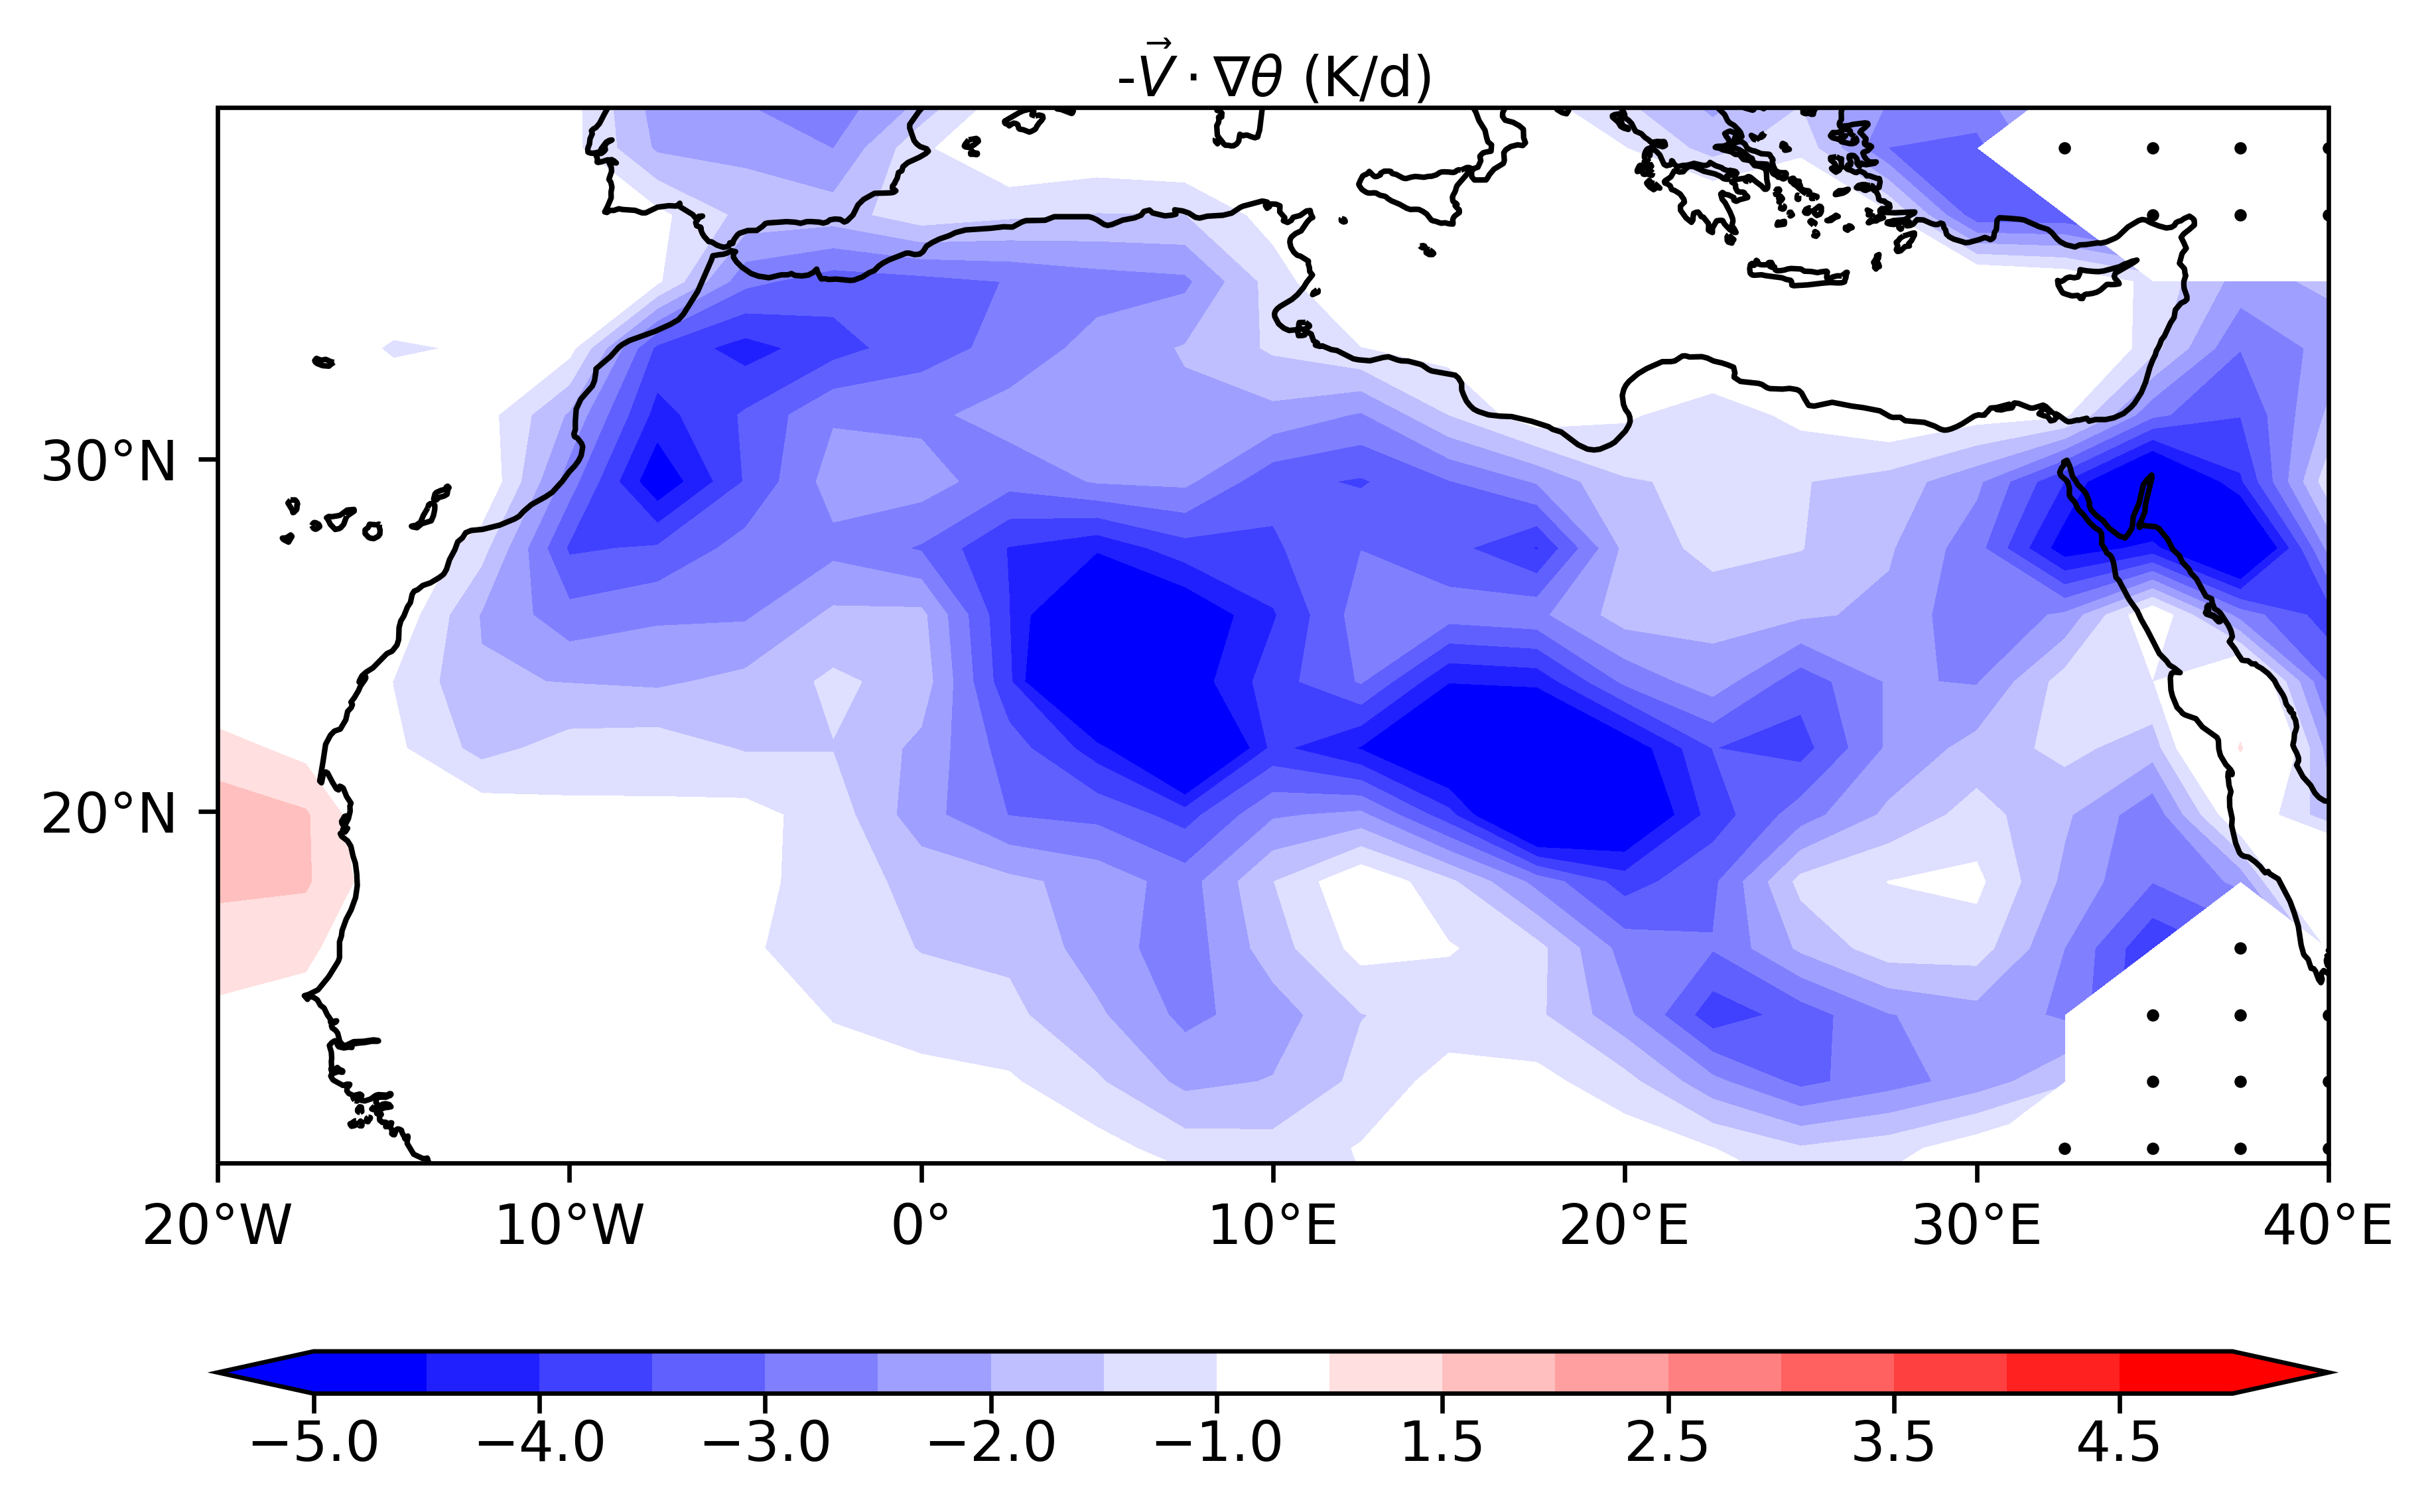

In [6]:
fig = plt.figure(figsize=(6, 5),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
# var_smooth=mpcalc.smooth_n_point(sen2sst_mean, 9, 1)
minVal = -5
maxVal = 5+0.5
cint = 0.5
intervals = np.arange(minVal, maxVal, cint) 

# intervals = np.array([-10,-])

# levels=np.array([-2,5])
# phi=-Tadv.sel(lev_p=900).mean(dim='time',skipna=False)
phi=-Tadv

# frac_missing=1-phi.count('time')/phi.sizes['time']
# mask = frac_missing<0.95
# vari=phi.where(mask).mean(dim='time')
vari=mask_missing(phi)
# var=-Tadv.sel(lev_p=900)
# frac_missing=1-var.count('time')/var.sizes['time']
# mask = frac_missing<=0.5
# var=var.where(mask)
# phi=var.mean(dim='time')

# phi=var.mean(dim='time')

# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(vari.mean(dim='time'), sigma=0.8, min_weight=0.25)
phi_plot = vari.mean(dim='time')
ax1,CF =plot_phi(ax,phi_plot*24*60*60,intervals)
fontsize=12
pad=0.5
# ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax.set_title(r"-$\vec V\cdot\nabla \theta$ (K/d)",fontsize=10,pad=1)

Text(0.5, 1.0, '-$\\vec V\\cdot\\nabla \\theta$ (K/d)')

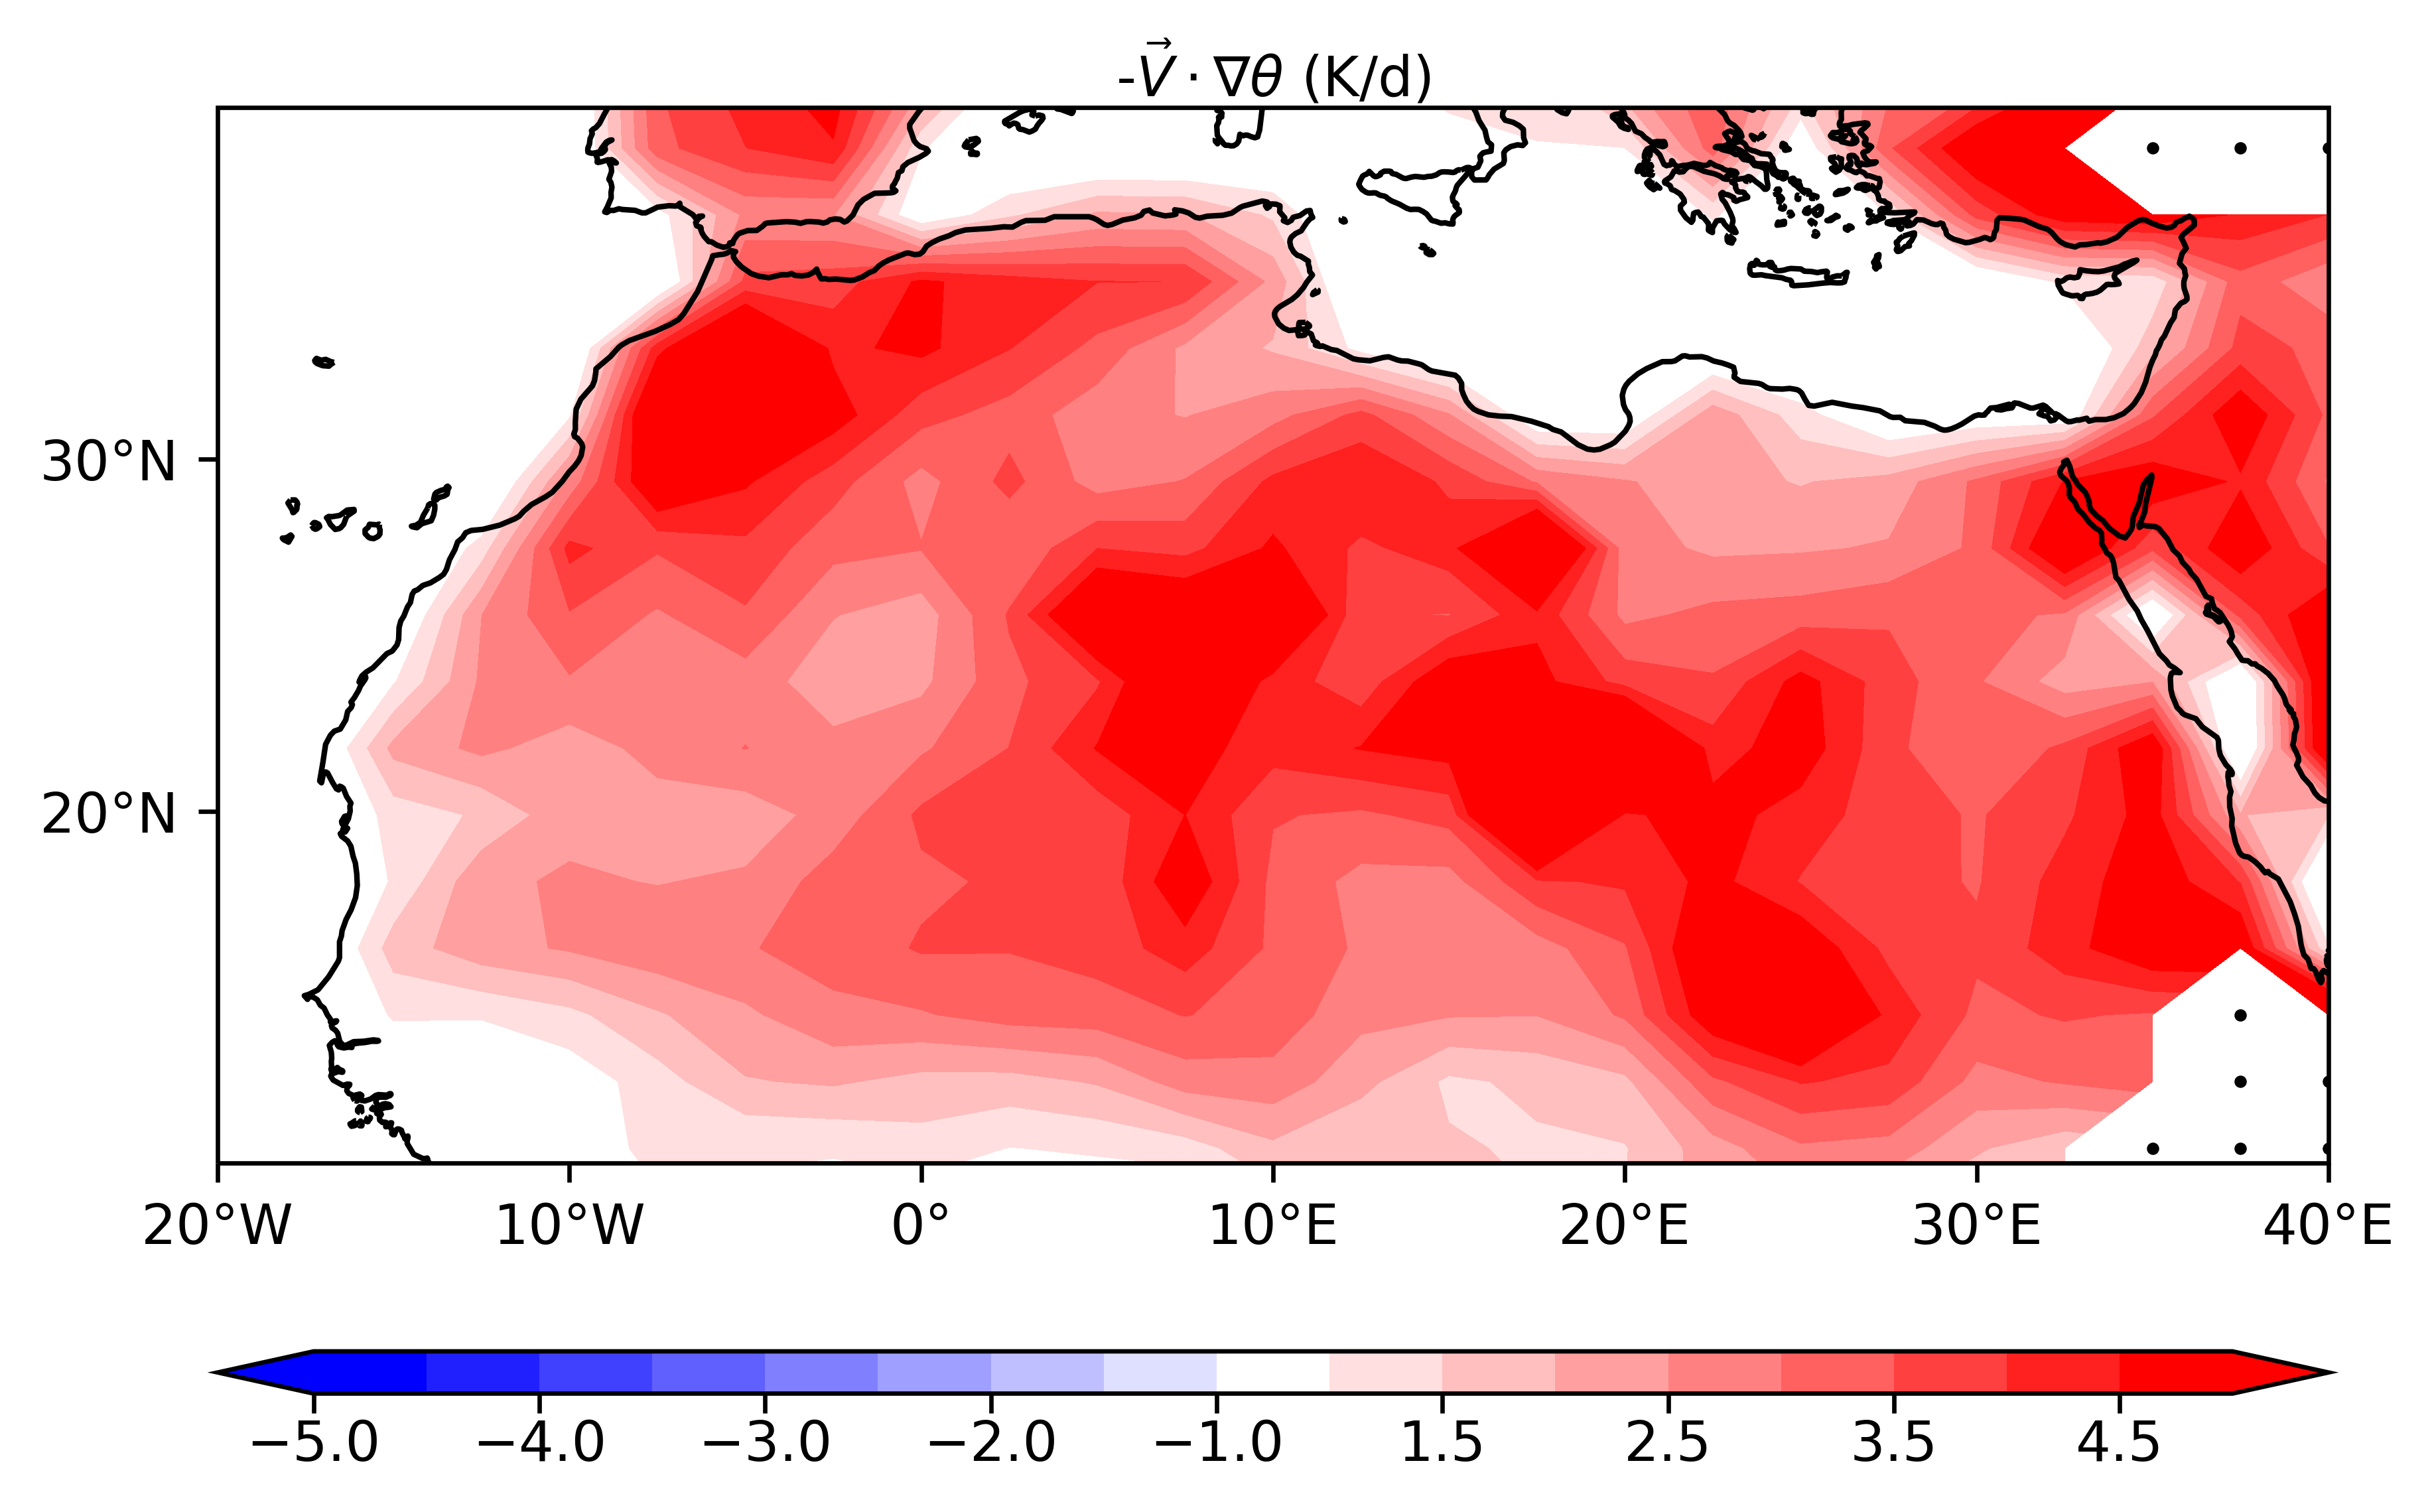

In [8]:
fig = plt.figure(figsize=(6, 5),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
# var_smooth=mpcalc.smooth_n_point(sen2sst_mean, 9, 1)
minVal = -5
maxVal = 5+0.5
cint = 0.5
intervals = np.arange(minVal, maxVal, cint) 

# intervals = np.array([-10,-])

# levels=np.array([-2,5])
# phi=-Tadv.sel(lev_p=900).mean(dim='time',skipna=False)
phi=DTV_theta

# frac_missing=1-phi.count('time')/phi.sizes['time']
# mask = frac_missing<0.95
vari=mask_missing(phi)
# var=-Tadv.sel(lev_p=900)
# frac_missing=1-var.count('time')/var.sizes['time']
# mask = frac_missing<=0.5
# var=var.where(mask)
# phi=var.mean(dim='time')

# phi=var.mean(dim='time')

# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(vari, sigma=0.8, min_weight=0.25)
phi_plot = vari.mean(dim='time')
ax1,CF =plot_phi(ax,phi_plot*24*60*60,intervals)
fontsize=12
pad=0.5
# ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax.set_title(r"-$\vec V\cdot\nabla \theta$ (K/d)",fontsize=10,pad=1)

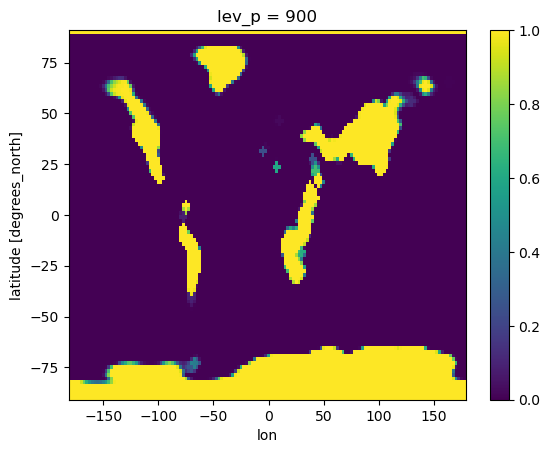

In [48]:
frac=test.isnull().mean(dim='time')
frac.plot()

Text(0.5, 1.0, '-$\\vec V\\cdot\\nabla \\theta$ (K/d)')

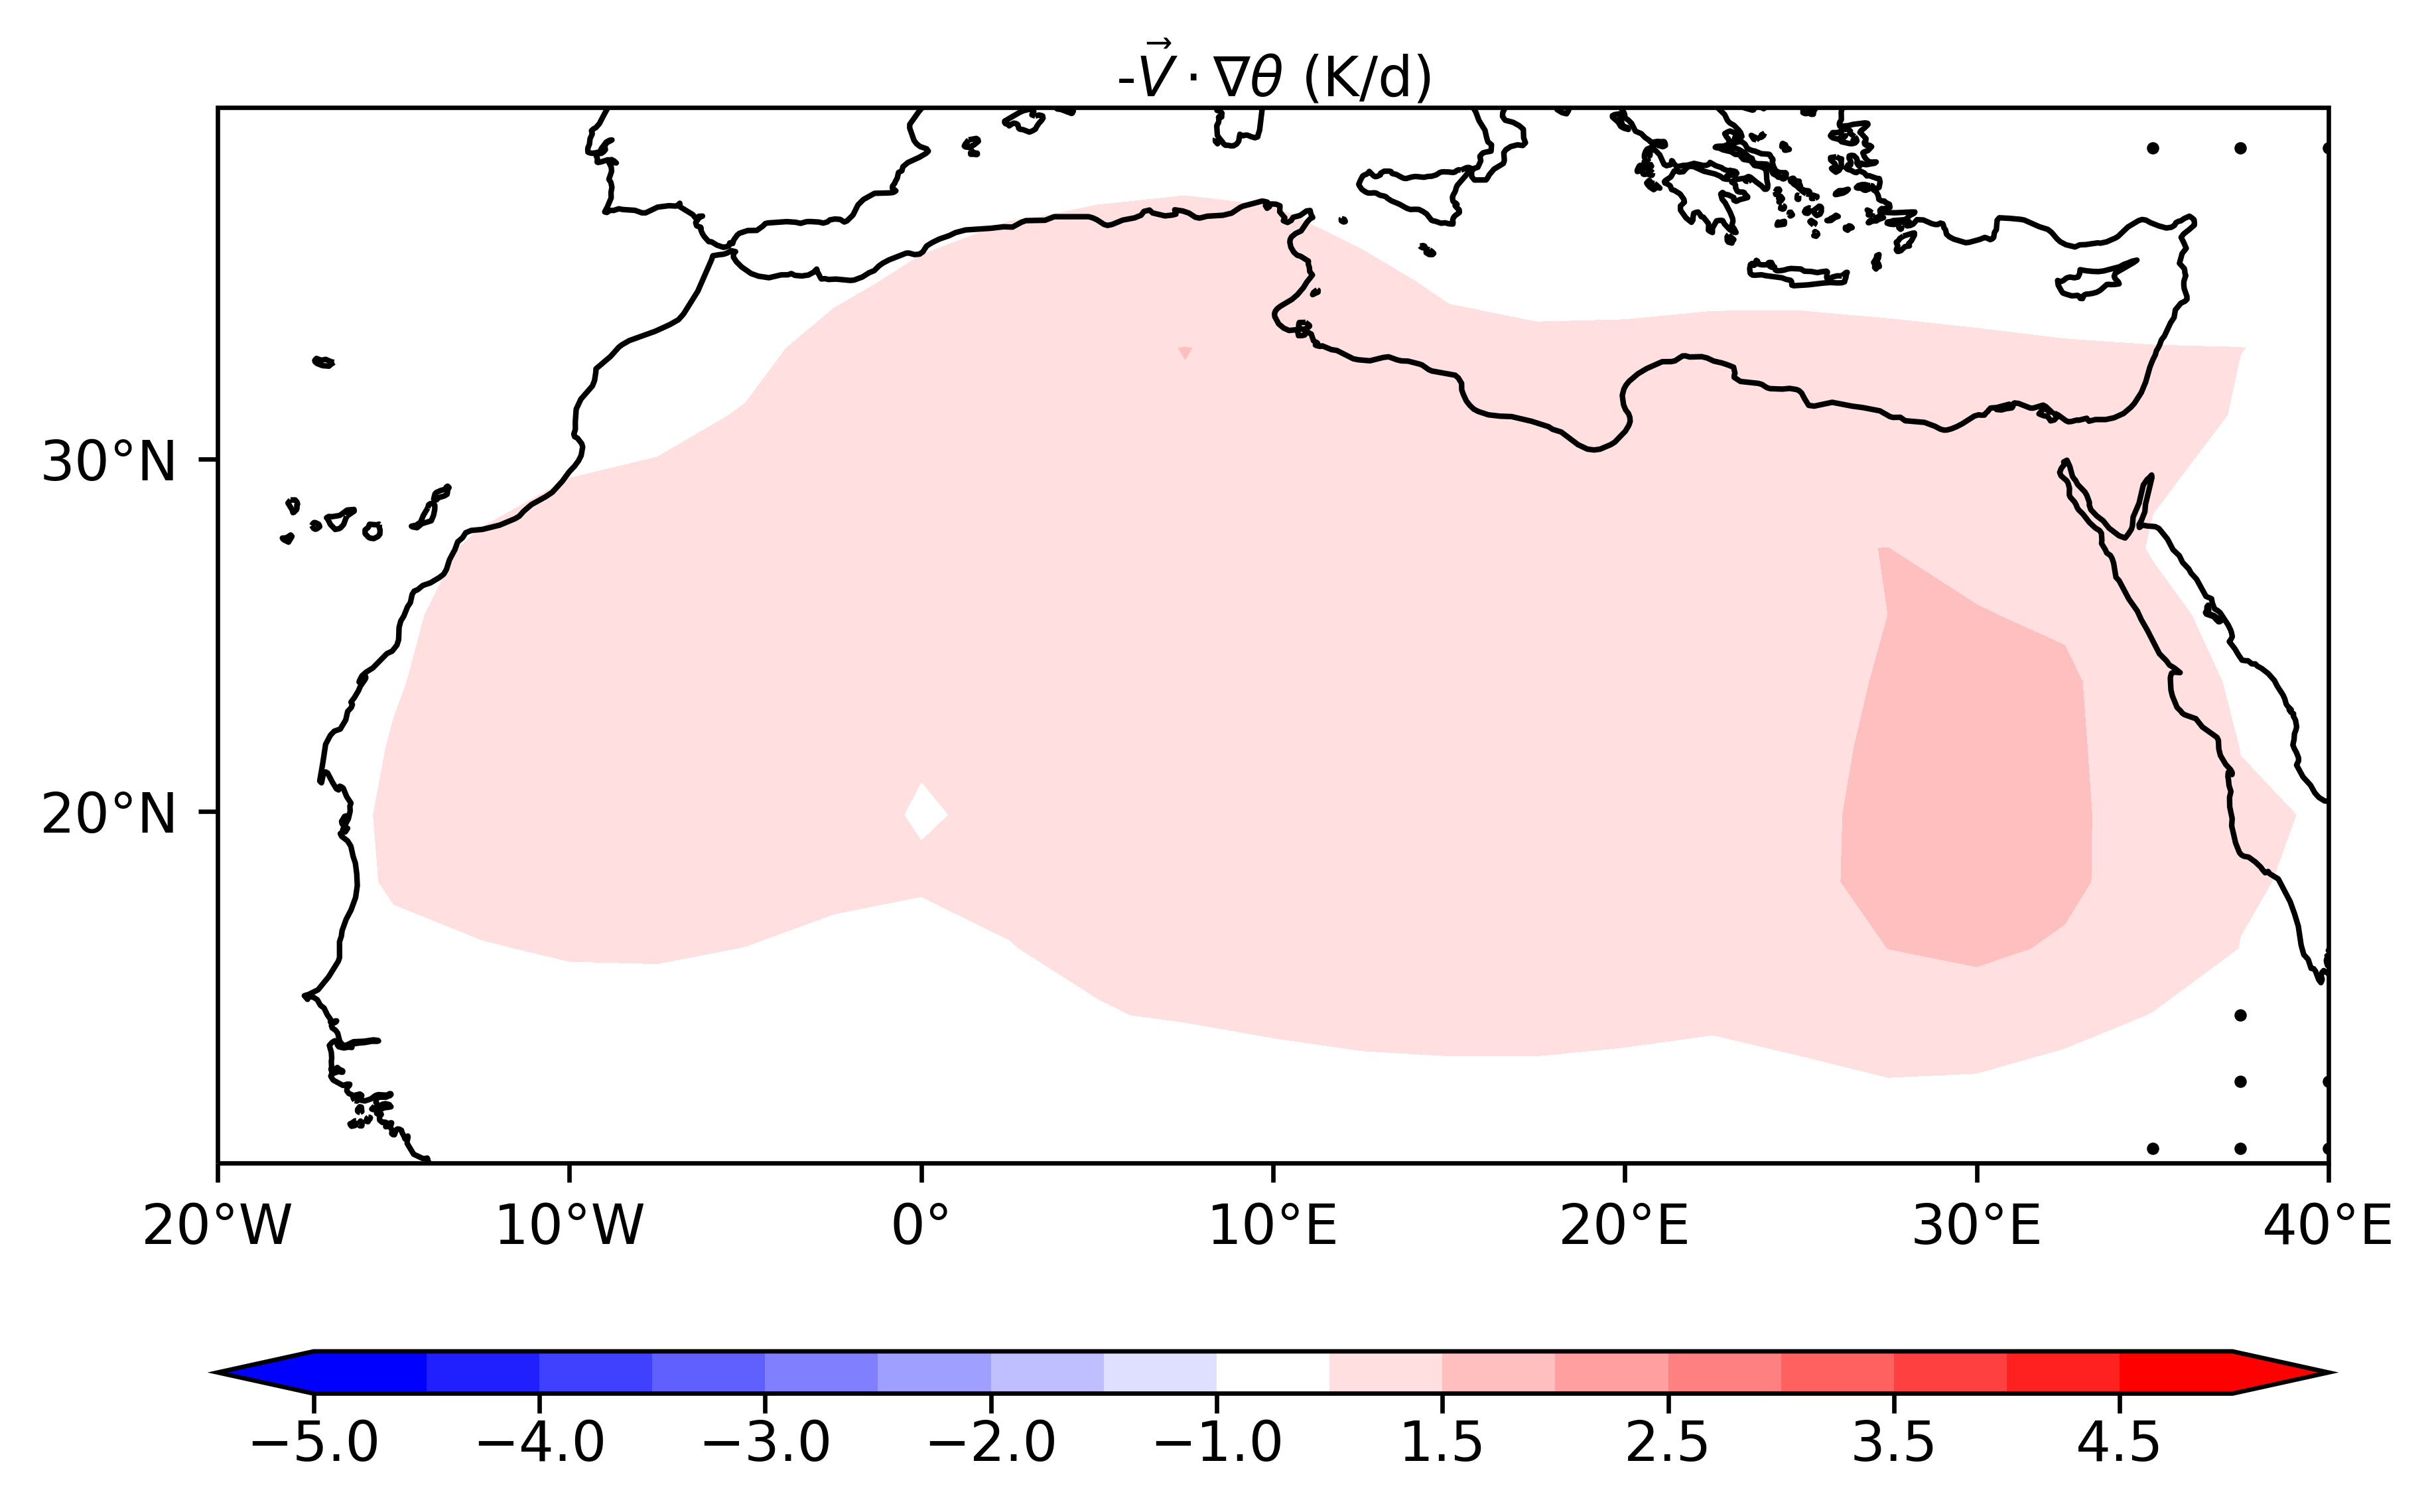

In [151]:
fig = plt.figure(figsize=(6, 5),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
# var_smooth=mpcalc.smooth_n_point(sen2sst_mean, 9, 1)
minVal = -5
maxVal = 5+0.5
cint = 0.5
intervals = np.arange(minVal, maxVal, cint) 

# intervals = np.array([-10,-])

# levels=np.array([-2,5])
# phi=-Tadv.sel(lev_p=900).mean(dim='time',skipna=False)
phi=QRS_theta.mean(dim='time')

# var=-Tadv.sel(lev_p=900)
# frac_missing=1-var.count('time')/var.sizes['time']
# mask = frac_missing<=0.5
# var=var.where(mask)
# phi=var.mean(dim='time')

# phi=var.mean(dim='time')

# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax1,CF =plot_phi(ax,phi_plot*24*60*60,intervals)
fontsize=12
pad=0.5
# ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax.set_title(r"-$\vec V\cdot\nabla \theta$ (K/d)",fontsize=10,pad=1)

Text(0.5, 1.0, '-$\\vec V\\cdot\\nabla \\theta$ (K/d)')

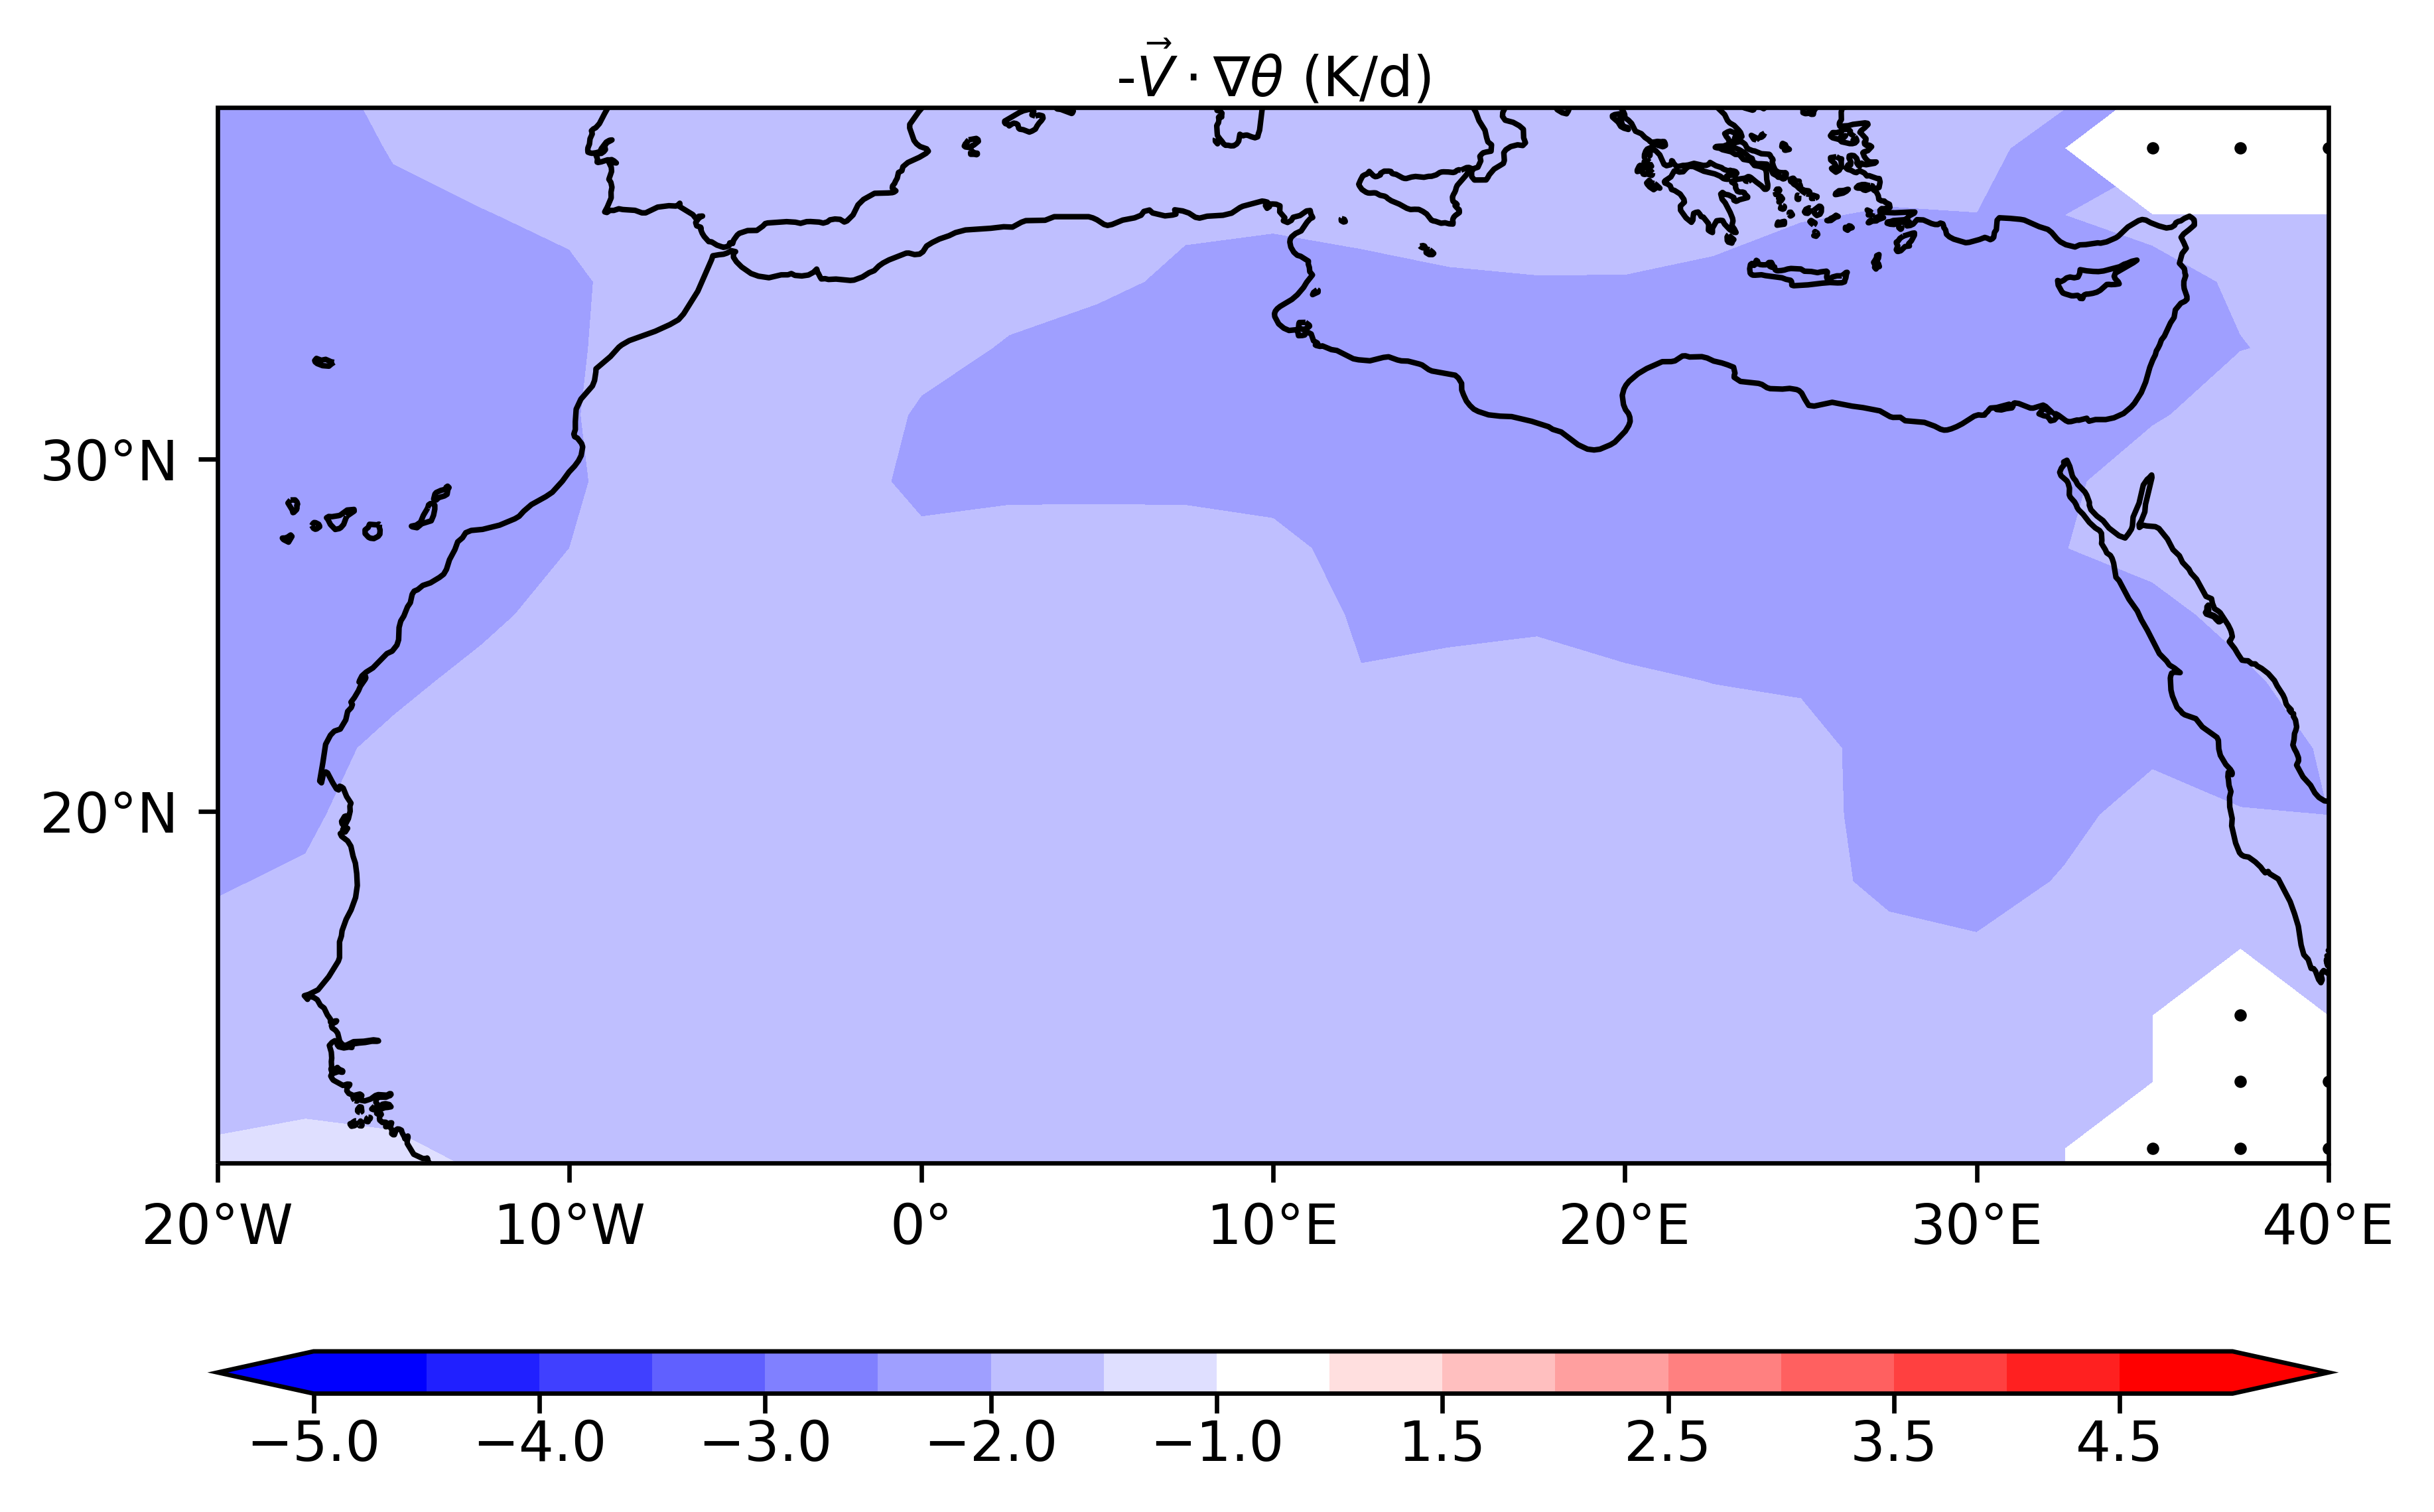

In [152]:
fig = plt.figure(figsize=(6, 5),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
# var_smooth=mpcalc.smooth_n_point(sen2sst_mean, 9, 1)
minVal = -5
maxVal = 5+0.5
cint = 0.5
intervals = np.arange(minVal, maxVal, cint) 

# intervals = np.array([-10,-])

# levels=np.array([-2,5])
# phi=-Tadv.sel(lev_p=900).mean(dim='time',skipna=False)
phi=QRL_theta.mean(dim='time')

# var=-Tadv.sel(lev_p=900)
# frac_missing=1-var.count('time')/var.sizes['time']
# mask = frac_missing<=0.5
# var=var.where(mask)
# phi=var.mean(dim='time')

# phi=var.mean(dim='time')

# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax1,CF =plot_phi(ax,phi_plot*24*60*60,intervals)
fontsize=12
pad=0.5
# ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax.set_title(r"-$\vec V\cdot\nabla \theta$ (K/d)",fontsize=10,pad=1)

Text(0.5, 1.0, '-$\\vec V\\cdot\\nabla \\theta$ (K/d)')

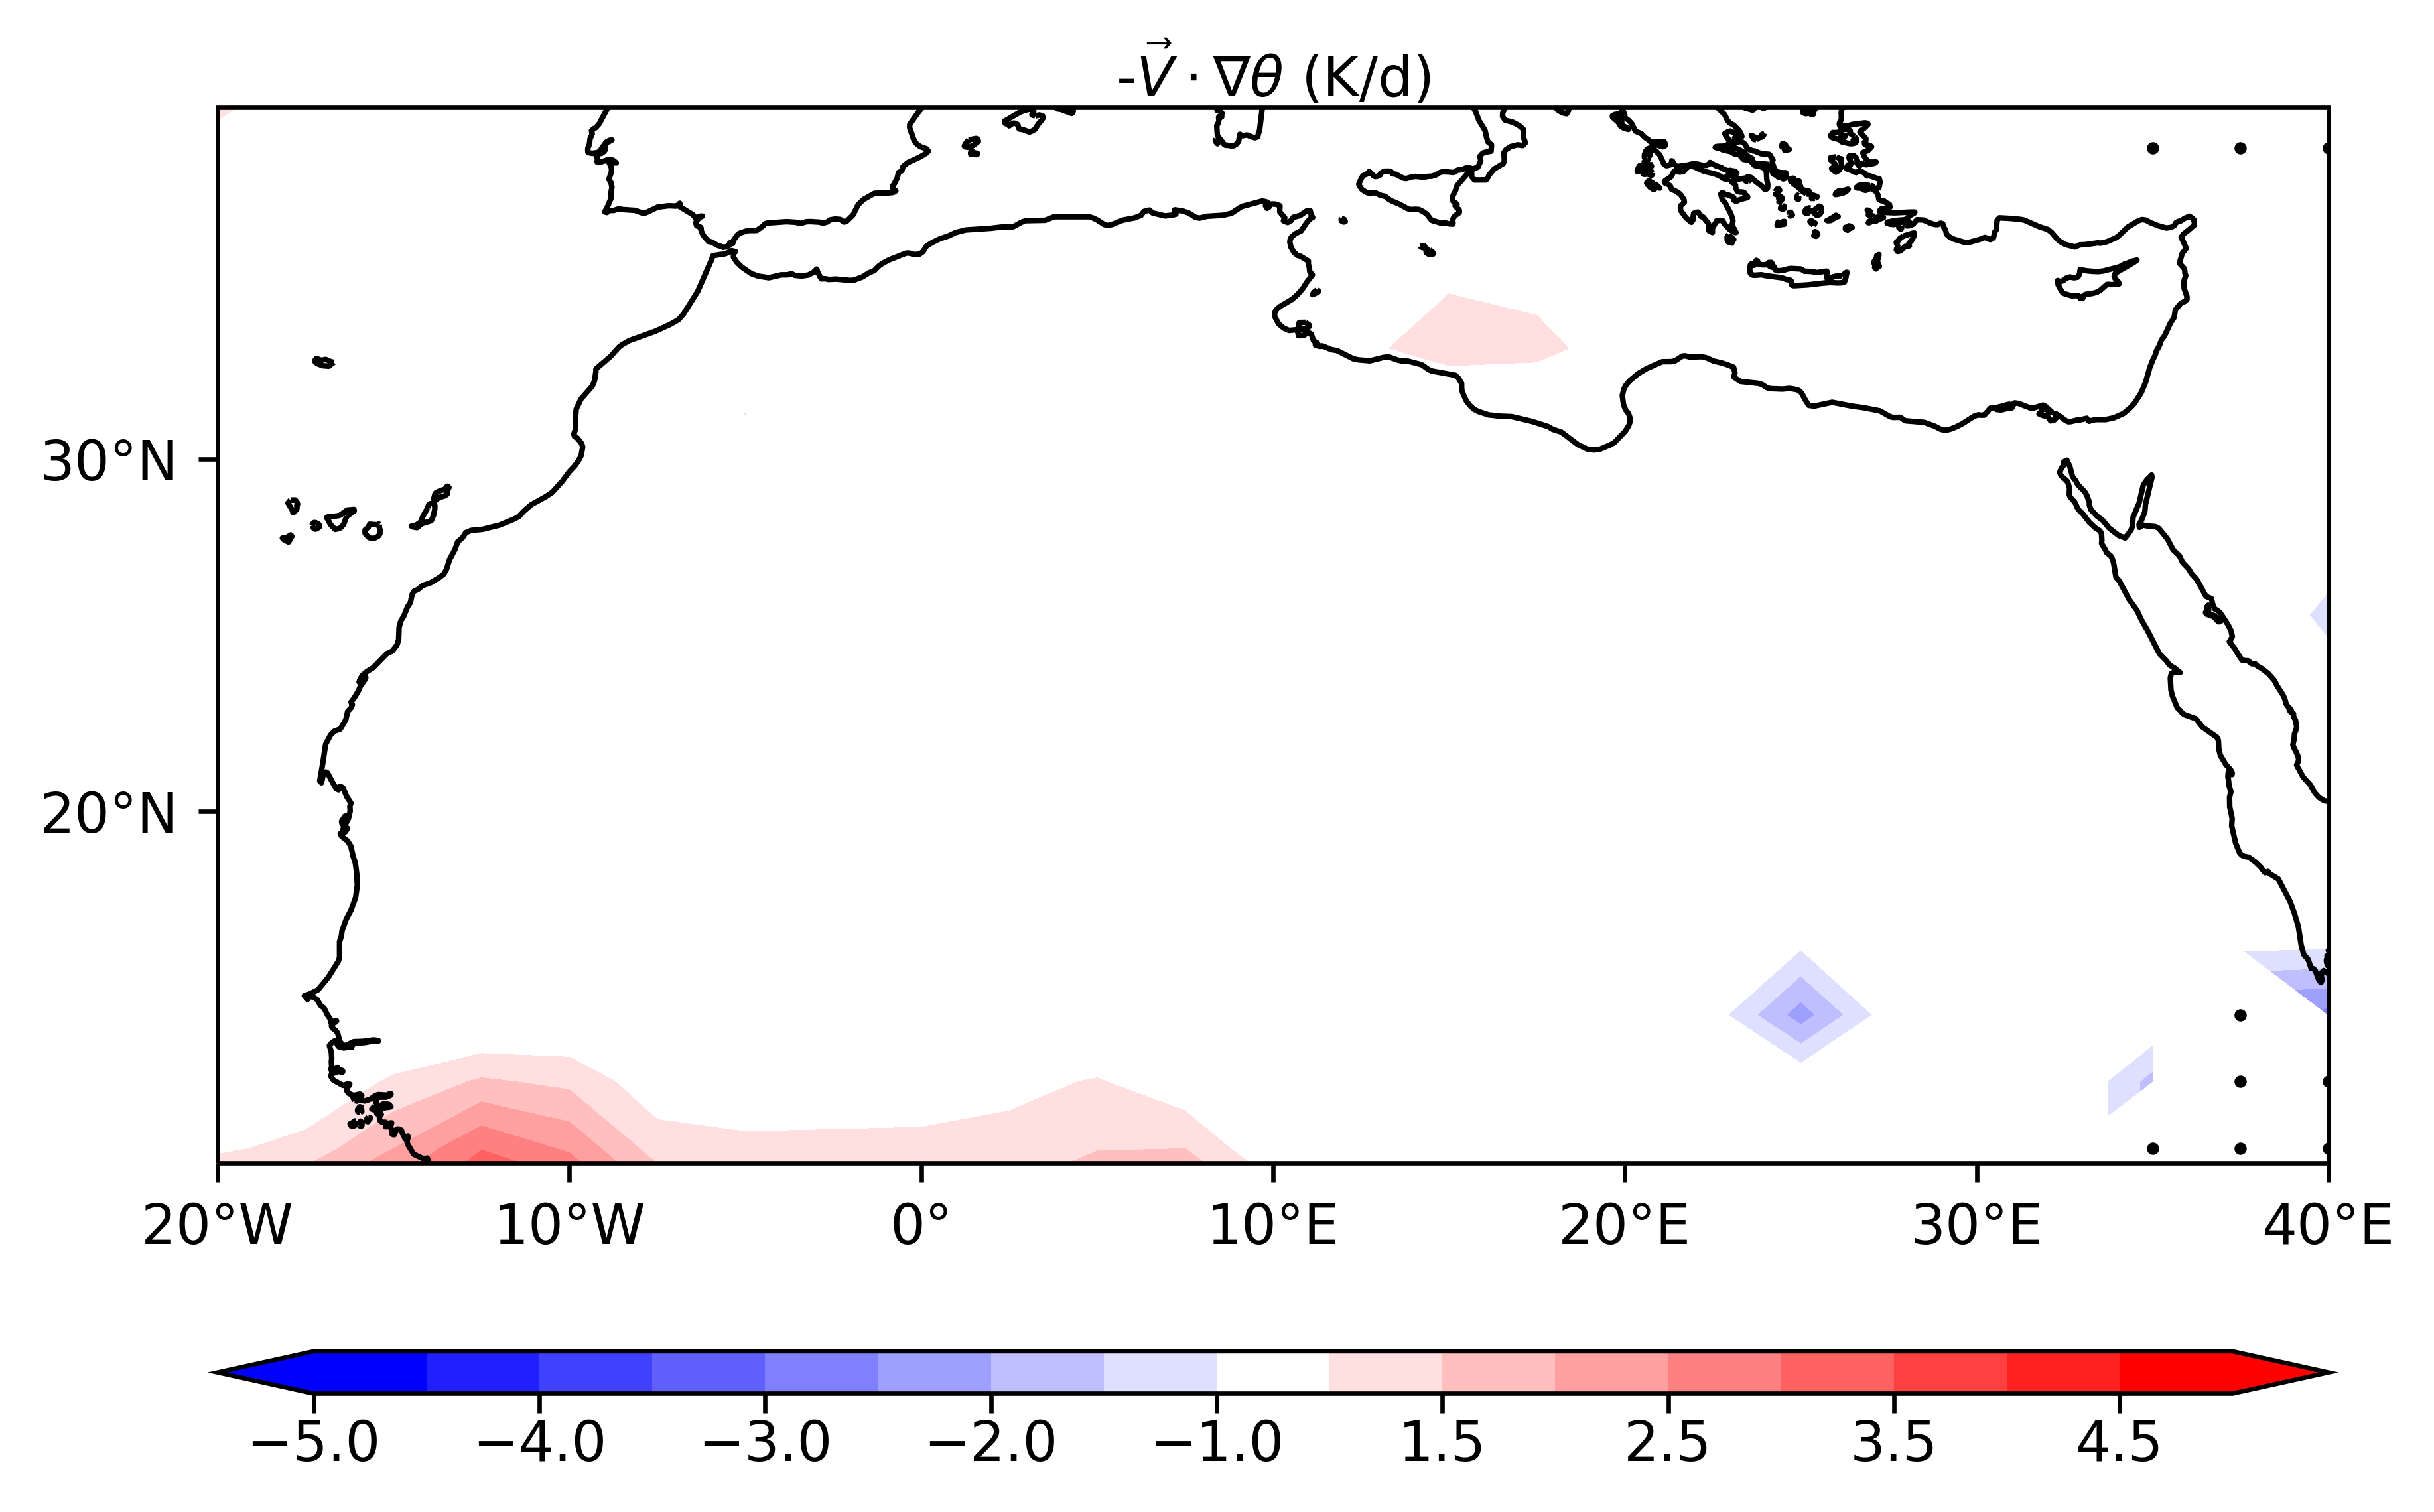

In [153]:
fig = plt.figure(figsize=(6, 5),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
# var_smooth=mpcalc.smooth_n_point(sen2sst_mean, 9, 1)
minVal = -5
maxVal = 5+0.5
cint = 0.5
intervals = np.arange(minVal, maxVal, cint) 

# intervals = np.array([-10,-])

# levels=np.array([-2,5])
# phi=-Tadv.sel(lev_p=900).mean(dim='time',skipna=False)
phi=DTCOND_theta.mean(dim='time')

# var=-Tadv.sel(lev_p=900)
# frac_missing=1-var.count('time')/var.sizes['time']
# mask = frac_missing<=0.5
# var=var.where(mask)
# phi=var.mean(dim='time')

# phi=var.mean(dim='time')

# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax1,CF =plot_phi(ax,phi*24*60*60,intervals)
fontsize=12
pad=0.5
# ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax.set_title(r"-$\vec V\cdot\nabla \theta$ (K/d)",fontsize=10,pad=1)

Text(0.5, 1.0, '-$\\vec V\\cdot\\nabla \\theta$ (K/d)')

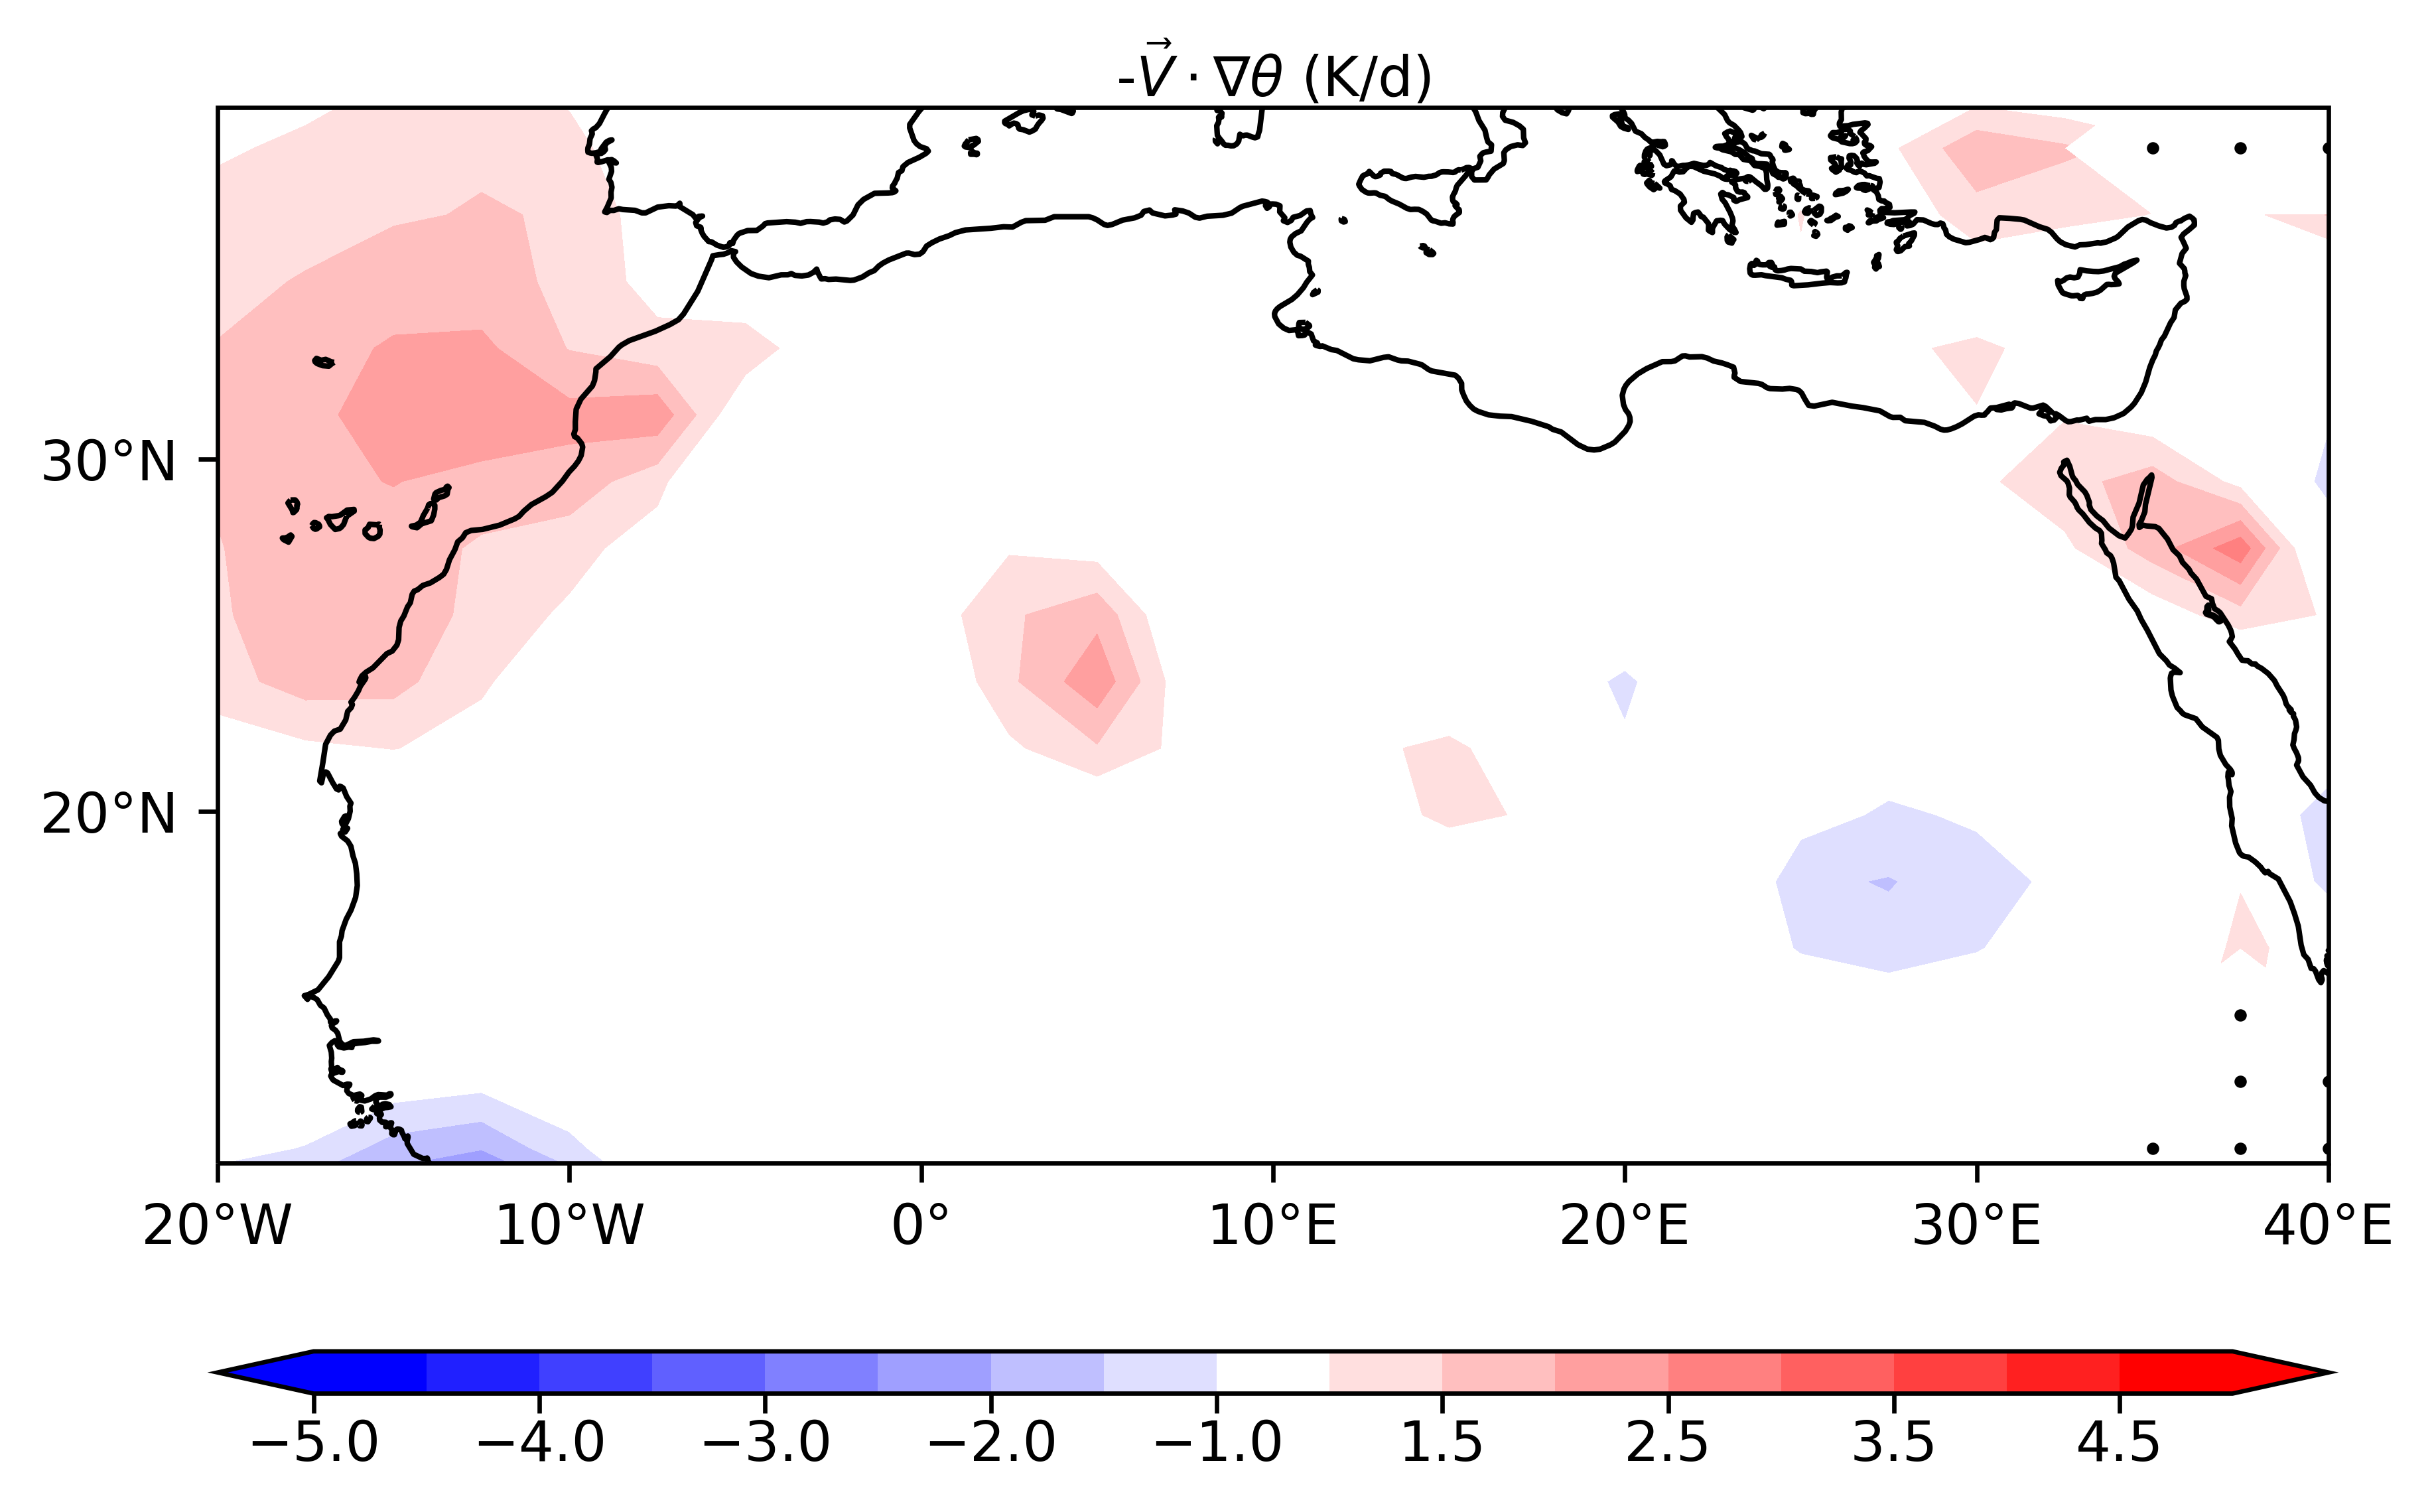

In [154]:
fig = plt.figure(figsize=(6, 5),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
# var_smooth=mpcalc.smooth_n_point(sen2sst_mean, 9, 1)
minVal = -5
maxVal = 5+0.5
cint = 0.5
intervals = np.arange(minVal, maxVal, cint) 

# intervals = np.array([-10,-])

# levels=np.array([-2,5])
# phi=-Tadv.sel(lev_p=900).mean(dim='time',skipna=False)
phi=-dpotdp.mean(dim='time')

# var=-Tadv.sel(lev_p=900)
# frac_missing=1-var.count('time')/var.sizes['time']
# mask = frac_missing<=0.5
# var=var.where(mask)
# phi=var.mean(dim='time')

# phi=var.mean(dim='time')

# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax1,CF =plot_phi(ax,phi*24*60*60,intervals)
fontsize=12
pad=0.5
# ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax.set_title(r"-$\vec V\cdot\nabla \theta$ (K/d)",fontsize=10,pad=1)

Text(0.5, 1.0, '-$\\vec V\\cdot\\nabla \\theta$ (K/d)')

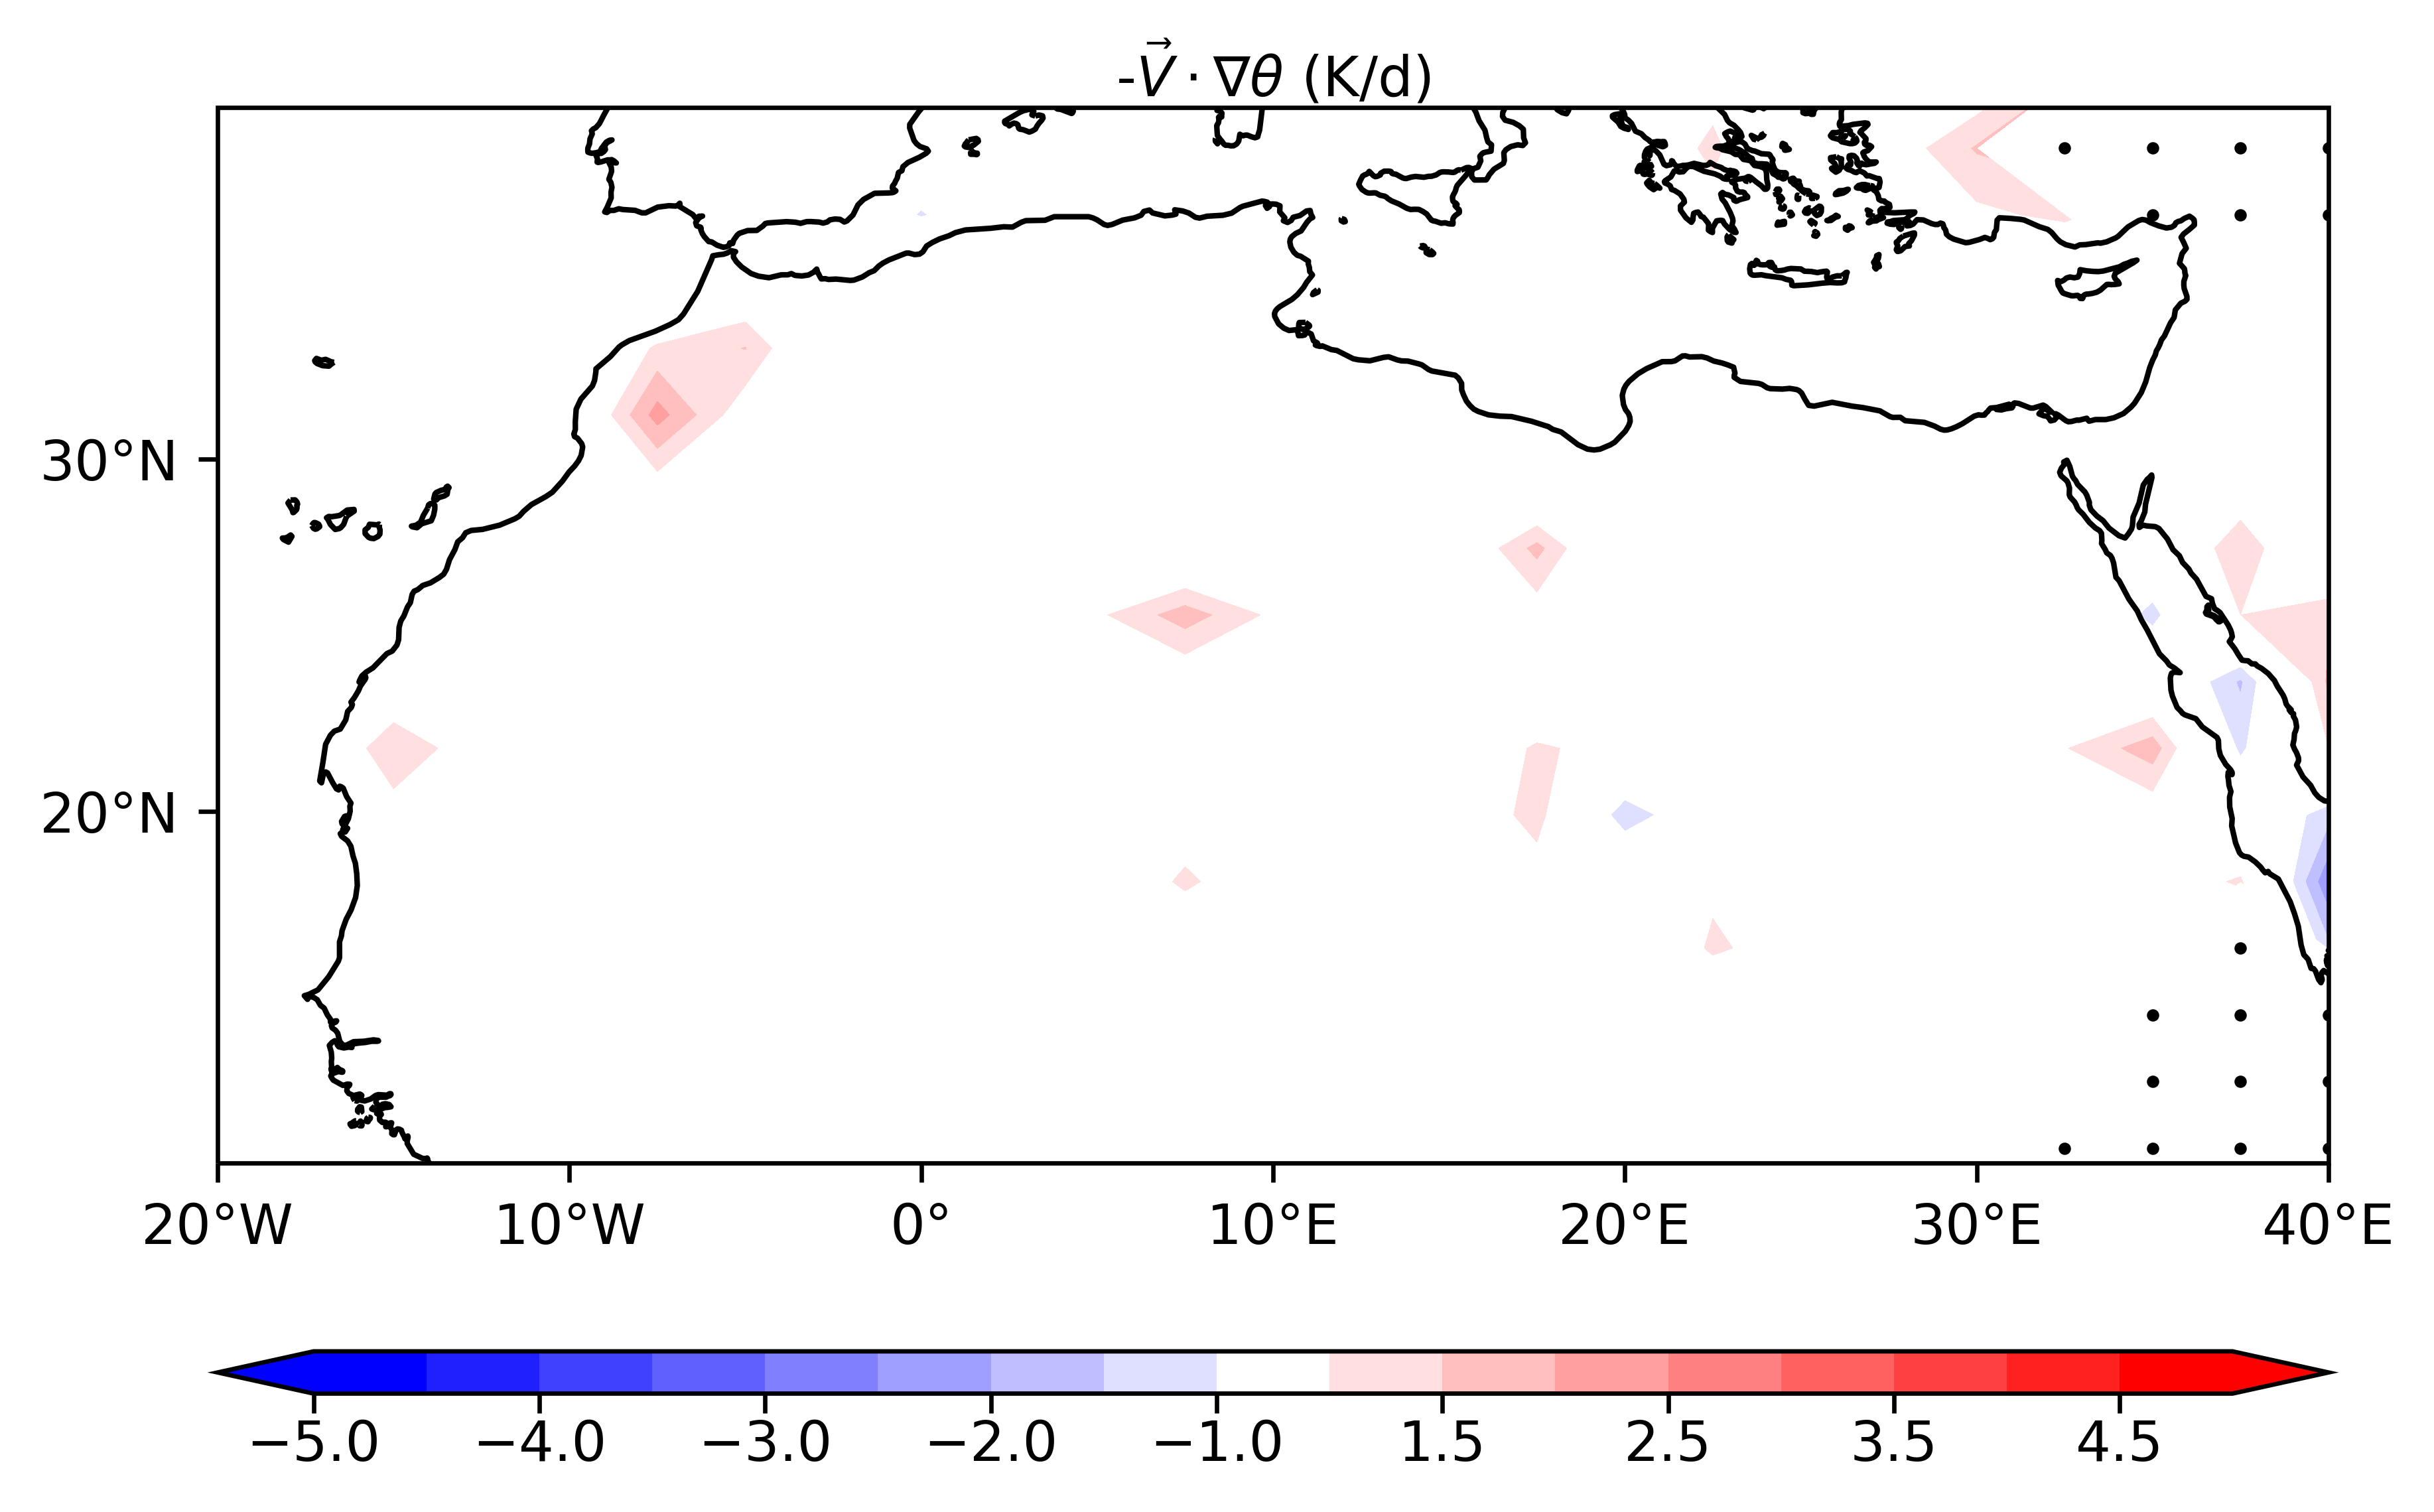

In [7]:
fig = plt.figure(figsize=(6, 5),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=1,
                        nrows=1)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
# var_smooth=mpcalc.smooth_n_point(sen2sst_mean, 9, 1)
minVal = -5
maxVal = 5+0.5
cint = 0.5
intervals = np.arange(minVal, maxVal, cint) 

# intervals = np.array([-10,-])

# levels=np.array([-2,5])
# phi=-Tadv.sel(lev_p=900).mean(dim='time',skipna=False)
phi=test.mean(dim='time')

# var=-Tadv.sel(lev_p=900)
# frac_missing=1-var.count('time')/var.sizes['time']
# mask = frac_missing<=0.5
# var=var.where(mask)
# phi=var.mean(dim='time')

# phi=var.mean(dim='time')

# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax1,CF =plot_phi(ax,phi*24*60*60,intervals)
fontsize=12
pad=0.5
# ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax.set_title(r"-$\vec V\cdot\nabla \theta$ (K/d)",fontsize=10,pad=1)

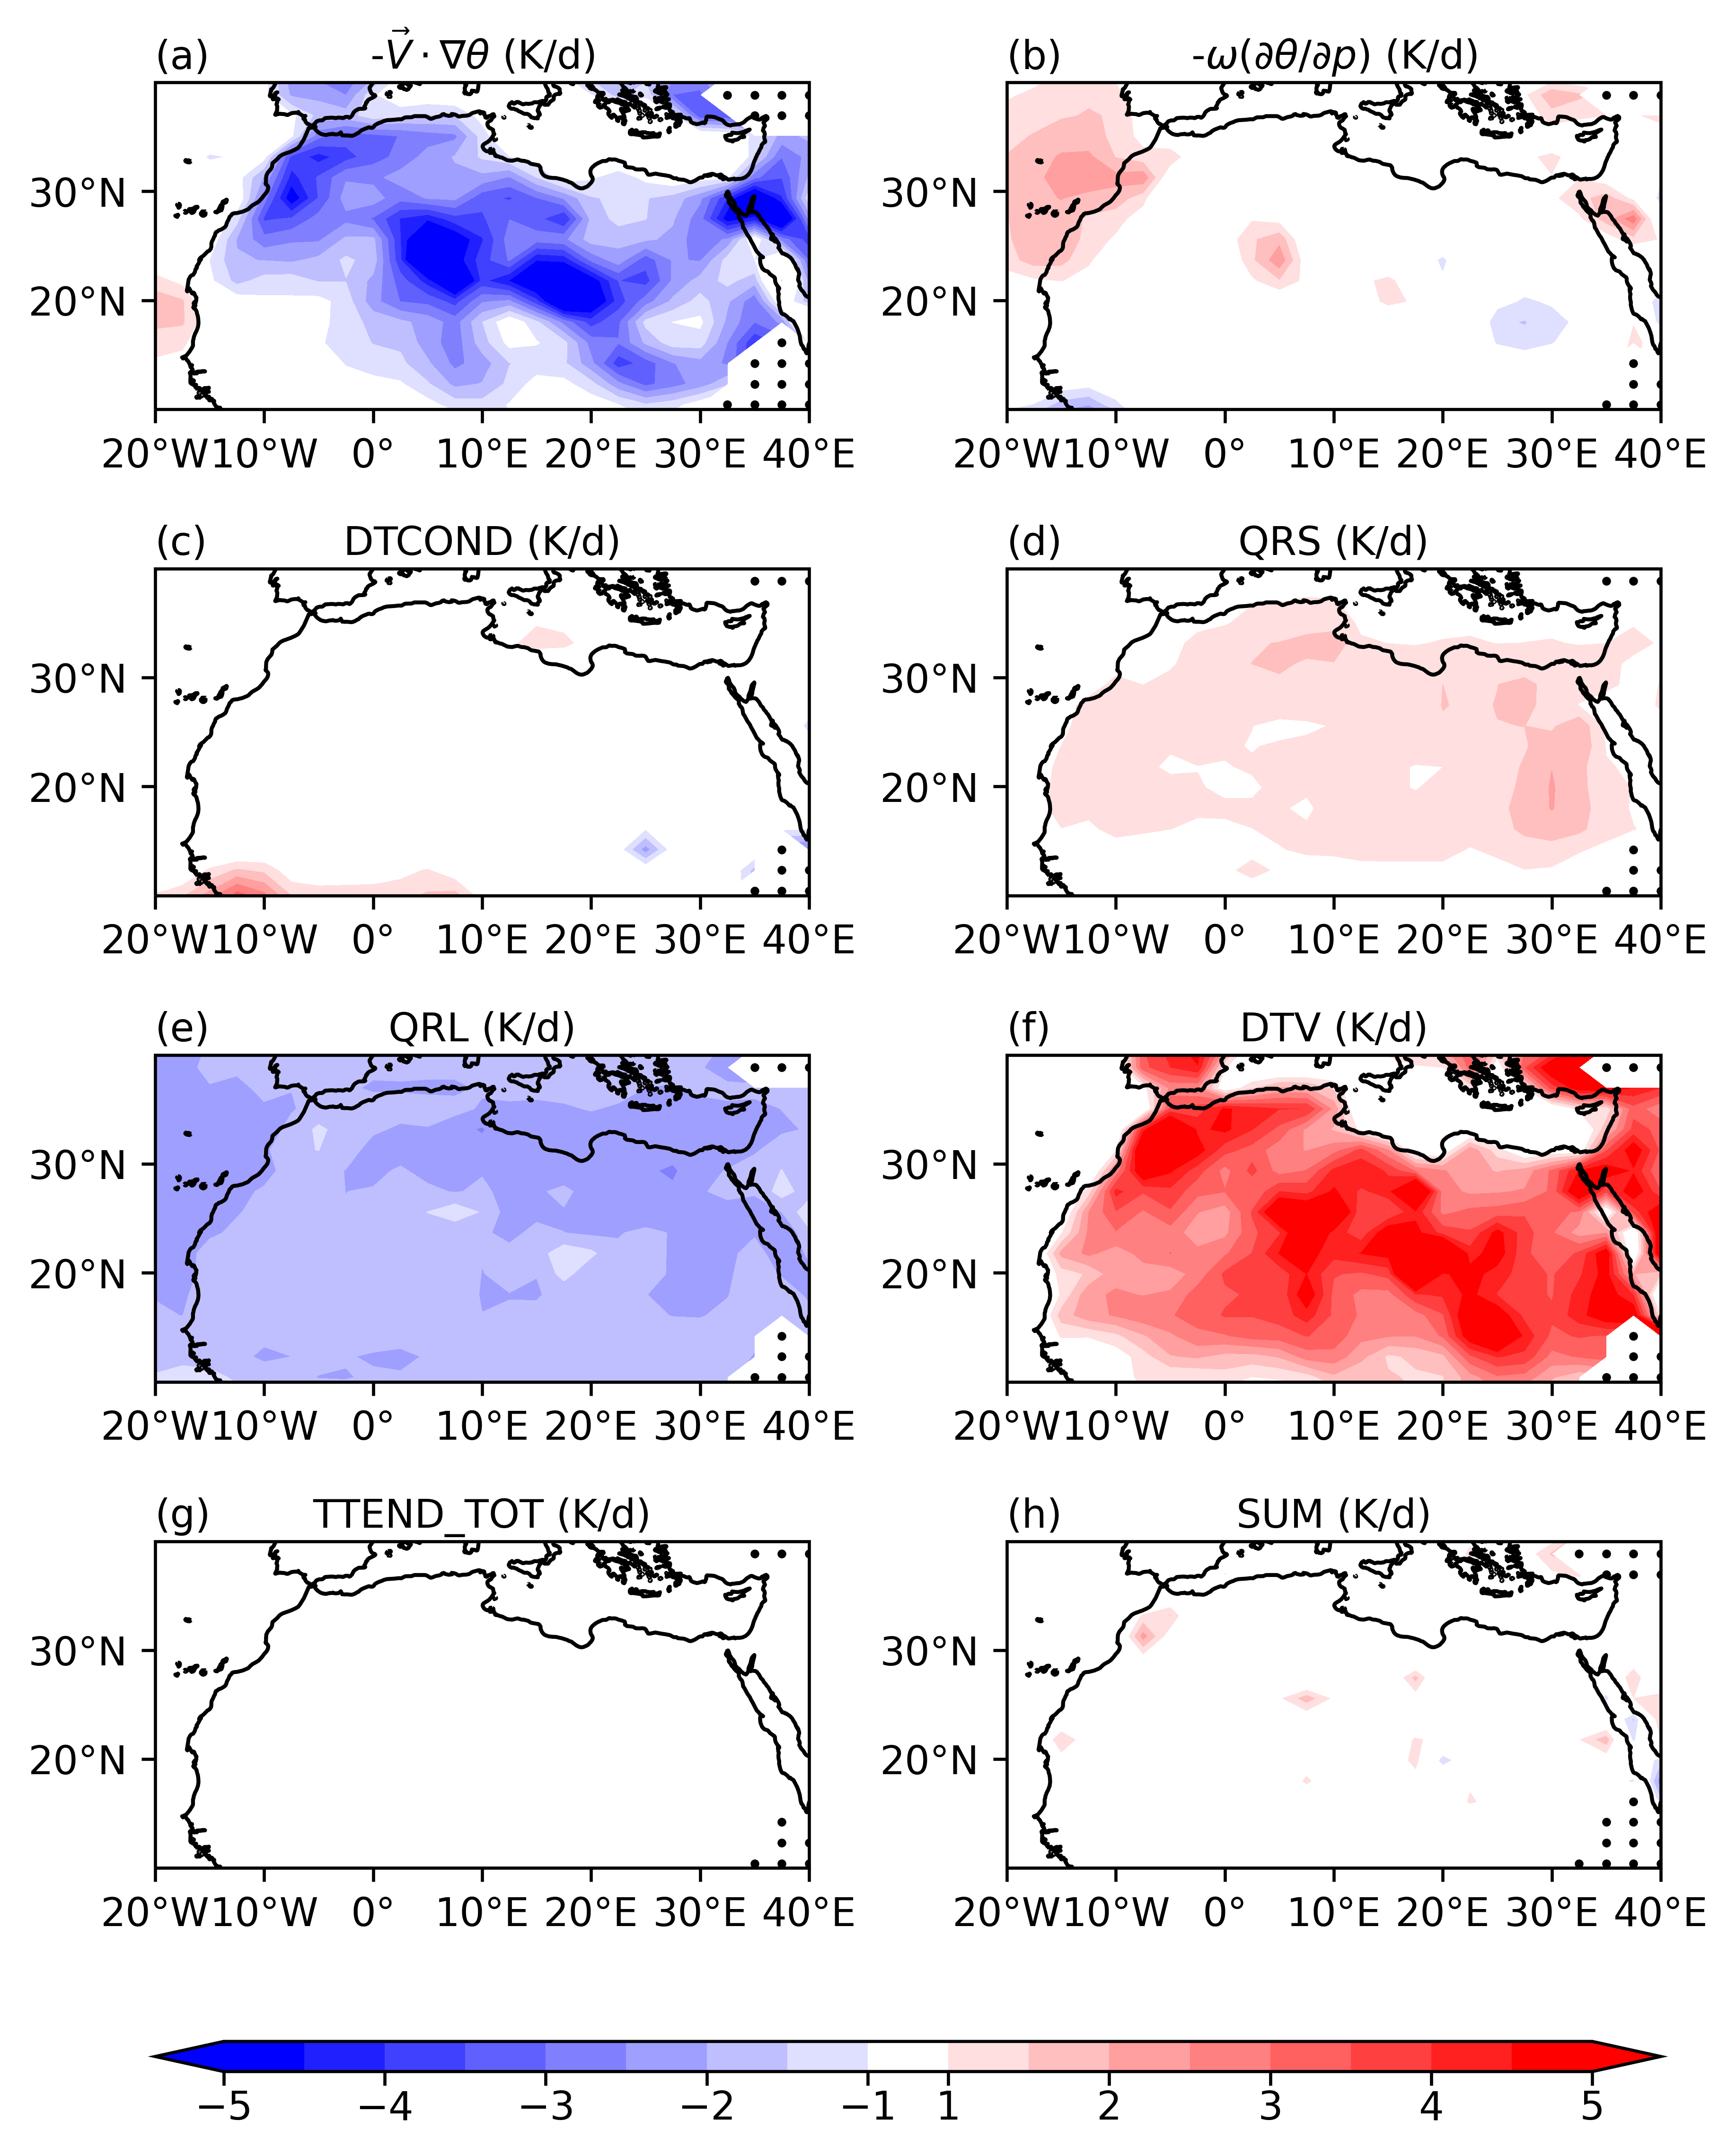

In [5]:
fig = plt.figure(figsize=(6, 7.5),dpi=600,constrained_layout=True)
grid = fig.add_gridspec(ncols=2,
                        nrows=4)

ax = fig.add_subplot(grid[0, 0],projection=ccrs.PlateCarree())
# var_smooth=mpcalc.smooth_n_point(sen2sst_mean, 9, 1)
minVal = -5
maxVal = 5+0.5
cint = 0.5
intervals = np.arange(minVal, maxVal, cint) 

# intervals = np.array([-10,-])

# levels=np.array([-2,5])
# phi=-Tadv.sel(lev_p=900).mean(dim='time',skipna=False)
phi=-Tadv.mean(dim='time')
phi_1=phi
# var=-Tadv.sel(lev_p=900)
# frac_missing=1-var.count('time')/var.sizes['time']
# mask = frac_missing<=0.5
# var=var.where(mask)
# phi=var.mean(dim='time')

# phi=var.mean(dim='time')

# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax1,CF =plot_phi(ax,phi*24*60*60,intervals)
fontsize=10
pad=3.5
# # ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
# cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
# cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax1.set_title(r"-$\vec V\cdot\nabla \theta$ (K/d)",fontsize=fontsize,pad=pad)
ax1.set_title("(a)",fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[0, 1],projection=ccrs.PlateCarree())
phi=-dpotdp.mean(dim='time')
phi_2=phi
# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax2,CF =plot_phi(ax,phi*24*60*60,intervals)
# # ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
# cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
# cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax2.set_title(r"-$\omega (\partial \theta/ \partial p)$ (K/d)",fontsize=fontsize,pad=pad)
ax2.set_title("(b)",fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[1, 0],projection=ccrs.PlateCarree())
phi=DTCOND_theta.mean(dim='time')
phi_3=phi
# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax3,CF =plot_phi(ax,phi*24*60*60,intervals)
# # ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
# cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
# cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax3.set_title("DTCOND (K/d)",fontsize=fontsize,pad=pad)
ax3.set_title("(c)",fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[1, 1],projection=ccrs.PlateCarree())
phi=QRS_theta.mean(dim='time')
phi_4=phi
# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax4,CF =plot_phi(ax,phi*24*60*60,intervals)
# # ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
# cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
# cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax4.set_title("QRS (K/d)",fontsize=fontsize,pad=pad)
ax4.set_title("(d)",fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[2, 0],projection=ccrs.PlateCarree())
phi=QRL_theta.mean(dim='time')
phi_5=phi
# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax5,CF =plot_phi(ax,phi*24*60*60,intervals)
# # ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
# cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
# cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax5.set_title("QRL (K/d)",fontsize=fontsize,pad=pad)
ax5.set_title("(e)",fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[2, 1],projection=ccrs.PlateCarree())
phi=DTV_theta.mean(dim='time')
phi_6=phi
# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax6,CF =plot_phi(ax,phi*24*60*60,intervals)
# # ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
# cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
# cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax6.set_title("DTV (K/d)",fontsize=fontsize,pad=pad)
ax6.set_title("(f)",fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[3, 0],projection=ccrs.PlateCarree())
phi=TTEND_TOT_theta_900.mean(dim='time')

# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax7,CF =plot_phi(ax,phi*24*60*60,intervals)
# # ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
# cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
# cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax7.set_title("TTEND_TOT (K/d)",fontsize=fontsize,pad=pad)
ax7.set_title("(g)",fontsize=fontsize,pad=pad,loc='left')

ax = fig.add_subplot(grid[3, 1],projection=ccrs.PlateCarree())
phi=test.mean(dim='time')

# phi_smooth=phi.rolling(lat=3, lon=3, center=True).mean()
# phi_plot = nan_gaussian_smooth_xr(phi, sigma=0.8, min_weight=0.25)
ax8,CF =plot_phi(ax,phi*24*60*60,intervals)
# # ax1.set_title('Sensitivity of Saharan SAT to SST',fontsize=fontsize,pad=pad)
# cbar=plt.colorbar(CF,ax=ax1,orientation="horizontal",aspect=50)
# cbar.ax.tick_params(axis="x",labelsize=10,pad=1)
ax8.set_title("SUM (K/d)",fontsize=fontsize,pad=pad)
ax8.set_title("(h)",fontsize=fontsize,pad=pad,loc='left')

cbar=plt.colorbar(CF,ax=[ax1,ax2,ax3,ax4,ax5,ax6,ax7,ax8],orientation="horizontal",aspect=50)
cbar.ax.tick_params(axis="x",labelsize=10,pad=1)

bounds = np.array([-5,-4,-3,-2,-1,1,2,3,4,5])
cbar.set_ticks(bounds)